# Generation of Synthetic Dataset


## 1. imports


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

## 2. Experimental Dataset sampling

Apple didn't exist until 1976 and didn't go public until 1980; Microsoft was founded in 1975 but only went public in 1986 — so there are no stock prices to sample in 1975 for either company. Even if pre-IPO valuations were somehow available, the companies were tiny partnerships with no resemblance to the tech giants whose post-IPO growth rates you'd be extrapolating backward. Gold and silver are a far better choice for a 1970–2025 simulation window, since both have been continuously traded on organized futures exchanges since the early 1970s.

### 2.1 Real Apple TS

Lade Apple-Kursdaten aus lokalem Cache: ../data/stock_prices/AAPL_2012-01-01_2026-06-12.csv

                Apple (AAPL) Tageskurse 2012–2026                
          (split-bereinigt, via Yahoo Finance, in USD)           
Datum            Kurs (USD)   Veränd. (%)    Veränd. (USD)
-----------------------------------------------------------------
2012-01-03     $     12.31         —               —
2012-01-04     $     12.38     +  0.54%       +$   0.07
2012-01-05     $     12.51     +  1.11%       +$   0.14
2012-01-06     $     12.64     +  1.05%       +$   0.13
2012-01-09     $     12.62       -0.16%       -$   0.02
2012-01-10     $     12.67     +  0.36%       +$   0.05
2012-01-11     $     12.65       -0.16%       -$   0.02
2012-01-12     $     12.61       -0.27%       -$   0.03
2012-01-13     $     12.57       -0.37%       -$   0.05
2012-01-17     $     12.71     +  1.16%       +$   0.15
2012-01-18     $     12.85     +  1.04%       +$   0.13
2012-01-19     $     12.80       -0.3

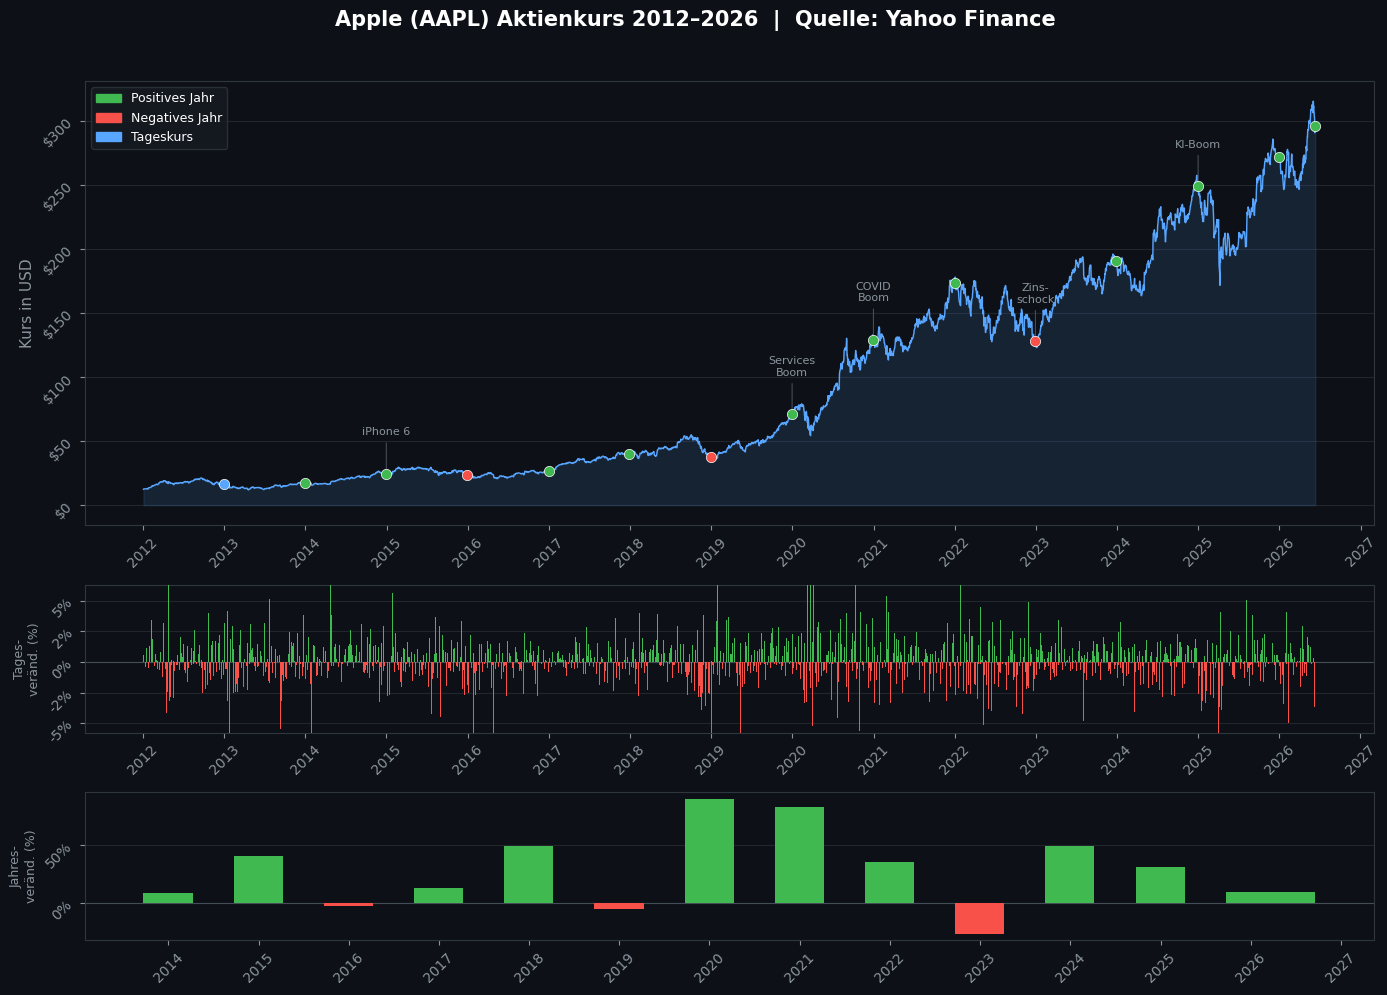

In [2]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Konfiguration ─────────────────────────────────────────────────
TICKER = "AAPL"
START = "2012-01-01"
END = "2026-06-12"
DATA_DIR = "../data/stock_prices"
CACHE_FILE = os.path.join(DATA_DIR, f"{TICKER}_{START}_{END}.csv")

# ── Daten laden (aus Cache oder von Yahoo Finance) ─────────────────
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Lade Apple-Kursdaten aus lokalem Cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
else:
    print("Lade Apple-Kursdaten von Yahoo Finance...")
    df = yf.download(TICKER, start=START, end=END, progress=False)
    df = df[["Close"]].copy()
    df.columns = ["Kurs"]
    df.index = df.index.tz_localize(None)  # Zeitzone entfernen
    df.to_csv(CACHE_FILE)
    print(f"Daten gespeichert unter: {CACHE_FILE}")

# Jahresschlusskurse
jahres = df.resample("YE").last()
jahres.index = jahres.index.year

# ── Tagesweise Konsolenausgabe ───────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Apple (AAPL) Tageskurse 2012–2026':^65}")
print(f"{'(split-bereinigt, via Yahoo Finance, in USD)':^65}")
print("=" * 65)
print(f"{'Datum':<14} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Veränd. (USD)'}")
print("-" * 65)

prev = None
for datum, row in df.iterrows():
    kurs = row["Kurs"]
    if prev is None:
        pct_str, abs_str = "      —", "       —"
    else:
        pct = (kurs - prev) / prev * 100
        absd = kurs - prev
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        abs_str = f"  +${absd:7.2f}" if absd >= 0 else f"  -${abs(absd):7.2f}"
    print(f"{str(datum.date()):<14} ${kurs:>10.2f}   {pct_str:<14} {abs_str}")
    prev = kurs

print("-" * 65)
gesamt = (df["Kurs"].iloc[-1] - df["Kurs"].iloc[0]) / df["Kurs"].iloc[0] * 100
print(f"{'Gesamtrendite:':<35} +{gesamt:.0f}%")
print(f"{'Aus $1.000 wurden:':<35} ${1000 * df['Kurs'].iloc[-1] / df['Kurs'].iloc[0]:,.0f}")
print("=" * 65)

# ── Jahresübersicht ──────────────────────────────────────────────
kurse_list = jahres["Kurs"].tolist()
jahre_list = jahres.index.tolist()

print("\n" + "=" * 55)
print(f"{'Jahresübersicht':^55}")
print("=" * 55)
print(f"{'Jahr':<8} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Trend'}")
print("-" * 55)
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        pct_str, trend = "      —", ""
    else:
        pct = (kurs - kurse_list[i - 1]) / kurse_list[i - 1] * 100
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        trend = "▲" * min(int(abs(pct) / 15) + 1, 5) if pct >= 0 else "▼"
    hinweis = " ← aktuell" if i == len(jahre_list) - 1 else ""
    print(f"{jahr:<8} ${kurs:>10.2f}   {pct_str:<14} {trend}{hinweis}")
print("=" * 55)

# ── Grafik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 1, 1]},
    facecolor="#0d1117"
)
ax1, ax2, ax3 = axes
fig.suptitle(
    "Apple (AAPL) Aktienkurs 2012–2026  |  Quelle: Yahoo Finance",
    color="white", fontsize=15, fontweight="bold", y=0.99
)

# — ax1: Tageskurs-Linie —
ax1.set_facecolor("#0d1117")
ax1.plot(df.index, df["Kurs"], color="#58a6ff", linewidth=1.0, zorder=3)
ax1.fill_between(df.index, df["Kurs"], alpha=0.12, color="#58a6ff", zorder=2)

# Jahrespunkte einfärben
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        farbe = "#58a6ff"
    else:
        farbe = "#3fb950" if kurs >= kurse_list[i - 1] else "#f85149"
    datum = df[df.index.year == jahr].index[-1]
    ax1.scatter(datum, kurs, color=farbe, s=55, zorder=4,
                edgecolors="white", linewidths=0.5)

# Ereignis-Annotationen
ereignisse = {
    2014: "iPhone 6",
    2019: "Services\nBoom",
    2020: "COVID\nBoom",
    2022: "Zins-\nschock",
    2024: "KI-Boom",
}
for jahr, label in ereignisse.items():
    if jahr in jahres.index:
        kurs = jahres.loc[jahr, "Kurs"]
        datum = df[df.index.year == jahr].index[-1]
        ax1.annotate(
            label, xy=(datum, kurs), xytext=(datum, kurs + 30),
            fontsize=8, color="#8b949e", ha="center",
            arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
        )

ax1.set_ylabel("Kurs in USD", color="#8b949e", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(colors="#8b949e", rotation=45)
for spine in ax1.spines.values():
    spine.set_edgecolor("#30363d")
ax1.grid(axis="y", color="#21262d", linewidth=0.8)
ax1.set_axisbelow(True)

# — ax2: tägliche Veränderung in % —
ax2.set_facecolor("#0d1117")
tages_pct = df["Kurs"].pct_change() * 100
farben_tag = ["#3fb950" if v >= 0 else "#f85149" for v in tages_pct]
ax2.bar(df.index, tages_pct, color=farben_tag, width=1.5, zorder=3)
ax2.axhline(0, color="#444c56", linewidth=0.8)
ax2.set_ylabel("Tages-\nveränd. (%)", color="#8b949e", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_ylim(tages_pct.quantile(0.005), tages_pct.quantile(0.995))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(colors="#8b949e", rotation=45)
for spine in ax2.spines.values():
    spine.set_edgecolor("#30363d")
ax2.grid(axis="y", color="#21262d", linewidth=0.8)
ax2.set_axisbelow(True)

# — ax3: jährliche Veränderung —
ax3.set_facecolor("#0d1117")
farben_j, werte_j, pos_j = [], [], []
for i in range(1, len(jahre_list)):
    pct = (kurse_list[i] - kurse_list[i - 1]) / kurse_list[i - 1] * 100
    datum = df[df.index.year == jahre_list[i]].index[-1]
    pos_j.append(datum)
    werte_j.append(pct)
    farben_j.append("#3fb950" if pct >= 0 else "#f85149")

ax3.bar(pos_j, werte_j, color=farben_j, width=200, zorder=3)
ax3.axhline(0, color="#444c56", linewidth=0.8)
ax3.set_ylabel("Jahres-\nveränd. (%)", color="#8b949e", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(colors="#8b949e", rotation=45)
for spine in ax3.spines.values():
    spine.set_edgecolor("#30363d")
ax3.grid(axis="y", color="#21262d", linewidth=0.8)
ax3.set_axisbelow(True)

# Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[
        Patch(color="#3fb950", label="Positives Jahr"),
        Patch(color="#f85149", label="Negatives Jahr"),
        Patch(color="#58a6ff", label="Tageskurs"),
    ],
    loc="upper left", facecolor="#161b22",
    edgecolor="#30363d", labelcolor="white", fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2.2 Real Microsoft TS

Lade Microsoft-Kursdaten aus lokalem Cache: ../data/stock_prices/MSFT_2012-01-01_2026-06-12.csv

              Microsoft (MSFT) Tageskurse 2012–2026              
          (split-bereinigt, via Yahoo Finance, in USD)           
Datum            Kurs (USD)   Veränd. (%)    Veränd. (USD)
-----------------------------------------------------------------
2012-01-03     $     20.87         —               —
2012-01-04     $     21.36     +  2.35%       +$   0.49
2012-01-05     $     21.58     +  1.02%       +$   0.22
2012-01-06     $     21.92     +  1.55%       +$   0.34
2012-01-09     $     21.63       -1.32%       -$   0.29
2012-01-10     $     21.71     +  0.36%       +$   0.08
2012-01-11     $     21.61       -0.43%       -$   0.09
2012-01-12     $     21.83     +  1.01%       +$   0.22
2012-01-13     $     22.03     +  0.89%       +$   0.19
2012-01-17     $     22.03     +  0.04%       +$   0.01
2012-01-18     $     22.01       -0.11%       -$   0.02
2012-01-19     $     21.93       

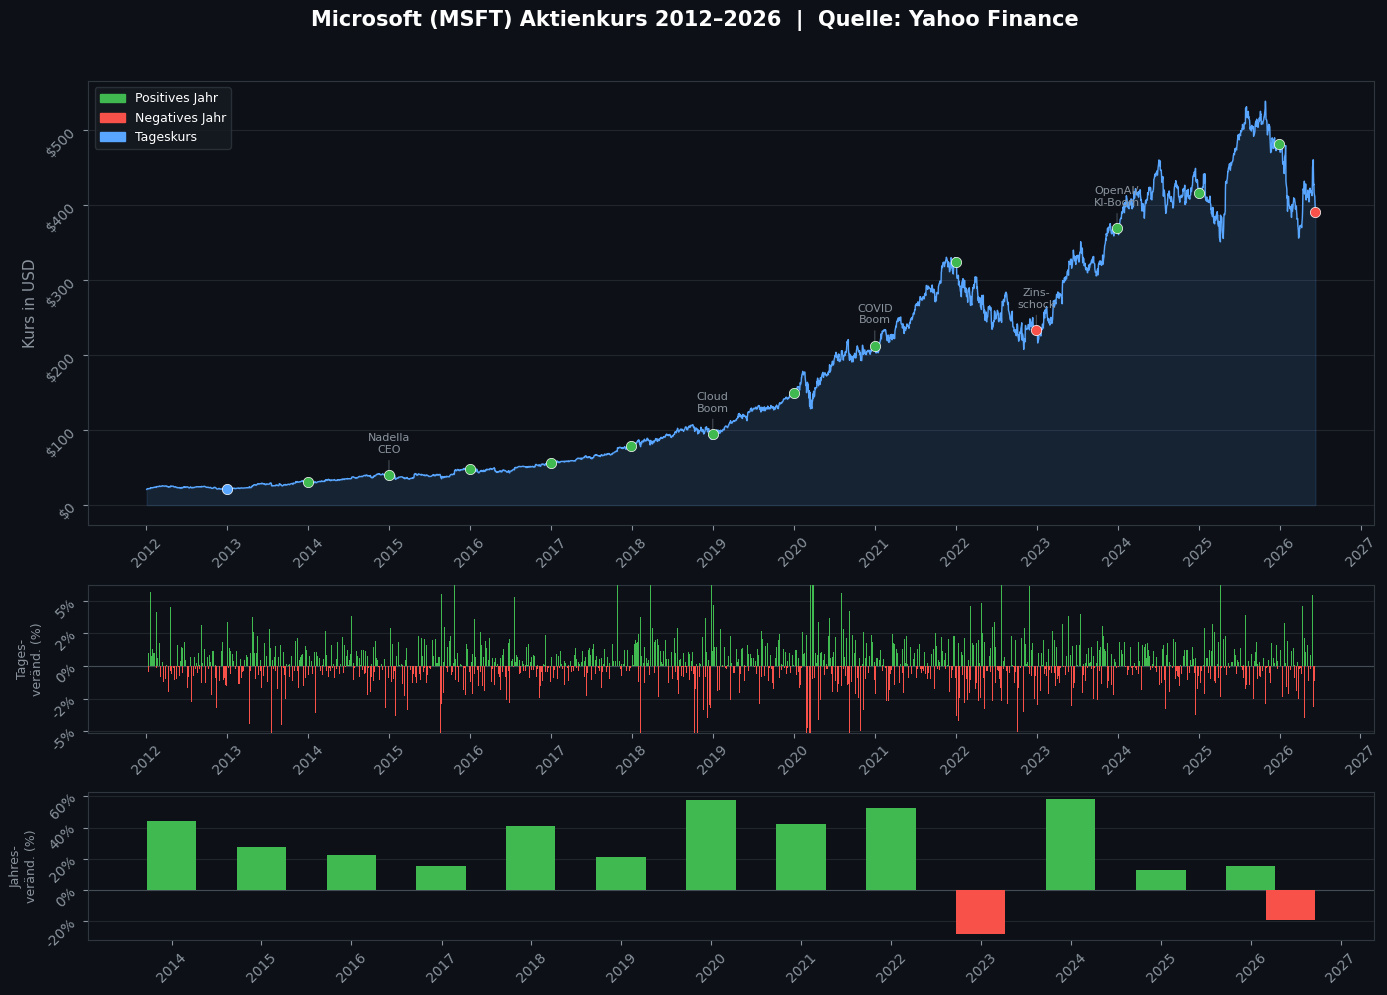

In [3]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Konfiguration ─────────────────────────────────────────────────
TICKER = "MSFT"
START = "2012-01-01"
END = "2026-06-12"
DATA_DIR = "../data/stock_prices"
CACHE_FILE = os.path.join(DATA_DIR, f"{TICKER}_{START}_{END}.csv")

# ── Daten laden (aus Cache oder von Yahoo Finance) ─────────────────
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Lade Microsoft-Kursdaten aus lokalem Cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
else:
    print("Lade Microsoft-Kursdaten von Yahoo Finance...")
    df = yf.download(TICKER, start=START, end=END, progress=False)
    df = df[["Close"]].copy()
    df.columns = ["Kurs"]
    df.index = df.index.tz_localize(None)  # Zeitzone entfernen
    df.to_csv(CACHE_FILE)
    print(f"Daten gespeichert unter: {CACHE_FILE}")

# Jahresschlusskurse
jahres = df.resample("YE").last()
jahres.index = jahres.index.year

# ── Tagesweise Konsolenausgabe ───────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Microsoft (MSFT) Tageskurse 2012–2026':^65}")
print(f"{'(split-bereinigt, via Yahoo Finance, in USD)':^65}")
print("=" * 65)
print(f"{'Datum':<14} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Veränd. (USD)'}")
print("-" * 65)

prev = None
for datum, row in df.iterrows():
    kurs = row["Kurs"]
    if prev is None:
        pct_str, abs_str = "      —", "       —"
    else:
        pct = (kurs - prev) / prev * 100
        absd = kurs - prev
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        abs_str = f"  +${absd:7.2f}" if absd >= 0 else f"  -${abs(absd):7.2f}"
    print(f"{str(datum.date()):<14} ${kurs:>10.2f}   {pct_str:<14} {abs_str}")
    prev = kurs

print("-" * 65)
gesamt = (df["Kurs"].iloc[-1] - df["Kurs"].iloc[0]) / df["Kurs"].iloc[0] * 100
print(f"{'Gesamtrendite:':<35} +{gesamt:.0f}%")
print(f"{'Aus $1.000 wurden:':<35} ${1000 * df['Kurs'].iloc[-1] / df['Kurs'].iloc[0]:,.0f}")
print("=" * 65)

# ── Jahresübersicht ──────────────────────────────────────────────
kurse_list = jahres["Kurs"].tolist()
jahre_list = jahres.index.tolist()

print("\n" + "=" * 55)
print(f"{'Jahresübersicht':^55}")
print("=" * 55)
print(f"{'Jahr':<8} {'Kurs (USD)':>12}   {'Veränd. (%)':<14} {'Trend'}")
print("-" * 55)
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        pct_str, trend = "      —", ""
    else:
        pct = (kurs - kurse_list[i - 1]) / kurse_list[i - 1] * 100
        pct_str = f"  +{pct:6.2f}%" if pct >= 0 else f"  {pct:7.2f}%"
        trend = "▲" * min(int(abs(pct) / 15) + 1, 5) if pct >= 0 else "▼"
    hinweis = " ← aktuell" if i == len(jahre_list) - 1 else ""
    print(f"{jahr:<8} ${kurs:>10.2f}   {pct_str:<14} {trend}{hinweis}")
print("=" * 55)

# ── Grafik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 1, 1]},
    facecolor="#0d1117"
)
ax1, ax2, ax3 = axes
fig.suptitle(
    "Microsoft (MSFT) Aktienkurs 2012–2026  |  Quelle: Yahoo Finance",
    color="white", fontsize=15, fontweight="bold", y=0.99
)

# — ax1: Tageskurs-Linie —
ax1.set_facecolor("#0d1117")
ax1.plot(df.index, df["Kurs"], color="#58a6ff", linewidth=1.0, zorder=3)
ax1.fill_between(df.index, df["Kurs"], alpha=0.12, color="#58a6ff", zorder=2)

# Jahrespunkte einfärben
for i, (jahr, kurs) in enumerate(zip(jahre_list, kurse_list)):
    if i == 0:
        farbe = "#58a6ff"
    else:
        farbe = "#3fb950" if kurs >= kurse_list[i - 1] else "#f85149"
    datum = df[df.index.year == jahr].index[-1]
    ax1.scatter(datum, kurs, color=farbe, s=55, zorder=4,
                edgecolors="white", linewidths=0.5)

# Ereignis-Annotationen
ereignisse = {
    2014: "Nadella\nCEO",
    2018: "Cloud\nBoom",
    2020: "COVID\nBoom",
    2022: "Zins-\nschock",
    2023: "OpenAI/\nKI-Boom",
}
for jahr, label in ereignisse.items():
    if jahr in jahres.index:
        kurs = jahres.loc[jahr, "Kurs"]
        datum = df[df.index.year == jahr].index[-1]
        ax1.annotate(
            label, xy=(datum, kurs), xytext=(datum, kurs + 30),
            fontsize=8, color="#8b949e", ha="center",
            arrowprops=dict(arrowstyle="-", color="#444c56", lw=0.8),
        )

ax1.set_ylabel("Kurs in USD", color="#8b949e", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(colors="#8b949e", rotation=45)
for spine in ax1.spines.values():
    spine.set_edgecolor("#30363d")
ax1.grid(axis="y", color="#21262d", linewidth=0.8)
ax1.set_axisbelow(True)

# — ax2: tägliche Veränderung in % —
ax2.set_facecolor("#0d1117")
tages_pct = df["Kurs"].pct_change() * 100
farben_tag = ["#3fb950" if v >= 0 else "#f85149" for v in tages_pct]
ax2.bar(df.index, tages_pct, color=farben_tag, width=1.5, zorder=3)
ax2.axhline(0, color="#444c56", linewidth=0.8)
ax2.set_ylabel("Tages-\nveränd. (%)", color="#8b949e", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.set_ylim(tages_pct.quantile(0.005), tages_pct.quantile(0.995))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(colors="#8b949e", rotation=45)
for spine in ax2.spines.values():
    spine.set_edgecolor("#30363d")
ax2.grid(axis="y", color="#21262d", linewidth=0.8)
ax2.set_axisbelow(True)

# — ax3: jährliche Veränderung —
ax3.set_facecolor("#0d1117")
farben_j, werte_j, pos_j = [], [], []
for i in range(1, len(jahre_list)):
    pct = (kurse_list[i] - kurse_list[i - 1]) / kurse_list[i - 1] * 100
    datum = df[df.index.year == jahre_list[i]].index[-1]
    pos_j.append(datum)
    werte_j.append(pct)
    farben_j.append("#3fb950" if pct >= 0 else "#f85149")

ax3.bar(pos_j, werte_j, color=farben_j, width=200, zorder=3)
ax3.axhline(0, color="#444c56", linewidth=0.8)
ax3.set_ylabel("Jahres-\nveränd. (%)", color="#8b949e", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(colors="#8b949e", rotation=45)
for spine in ax3.spines.values():
    spine.set_edgecolor("#30363d")
ax3.grid(axis="y", color="#21262d", linewidth=0.8)
ax3.set_axisbelow(True)

# Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[
        Patch(color="#3fb950", label="Positives Jahr"),
        Patch(color="#f85149", label="Negatives Jahr"),
        Patch(color="#58a6ff", label="Tageskurs"),
    ],
    loc="upper left", facecolor="#161b22",
    edgecolor="#30363d", labelcolor="white", fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2.3 Real Silver and Gold Stock TS

Gold and silver have been continuously traded on organized exchanges since the early 1970s, giving an uninterrupted 55-year price history with no IPO discontinuity and well-documented long-run properties — a stable exponential drift, known volatility regimes, and an empirically grounded return correlation of ~0.77–0.92. Their structural breaks also correspond to real, identifiable macroeconomic events (oil shocks, GFC, COVID), so the simulated DGP has external validity and a model trained on it is learning patterns that genuinely exist in real commodity markets.

seed = 7
n = 14610 trading days  (1970-01-01 to 2025-12-31,  ~58.0 years)
n_struc = 17

Achieved corr(returns) = 0.876  (target 0.82)
Achieved corr(levels)  = 0.948

Structural breaks (n_struc = 17):
  Break  1: 1974-04-18  gold=+0.13  silver=+0.14  h=491d  (back to normal 1976-03-05)
  Break  2: 1976-12-16  gold=-0.18  silver=-0.27  h=532d  (back to normal 1979-01-01)
  Break  3: 1979-11-15  gold=+0.08  silver=+0.15  h=679d  (back to normal 1982-06-23)
  Break  4: 1982-10-14  gold=+0.30  silver=+0.45  h=459d  (back to normal 1984-07-18)
  Break  5: 1986-01-29  gold=+0.12  silver=+0.22  h=595d  (back to normal 1988-05-11)
  Break  6: 1989-02-21  gold=+0.15  silver=+0.23  h=636d  (back to normal 1991-07-31)
  Break  7: 1992-03-09  gold=-0.32  silver=-0.44  h=215d  (back to normal 1993-01-04)
  Break  8: 1995-12-05  gold=+0.22  silver=+0.40  h= 98d  (back to normal 1996-04-19)
  Break  9: 1998-07-09  gold=-0.31  silver=-0.50  h=267d  (back to normal 1999-07-19)
  Break 10: 2001-03-05  go

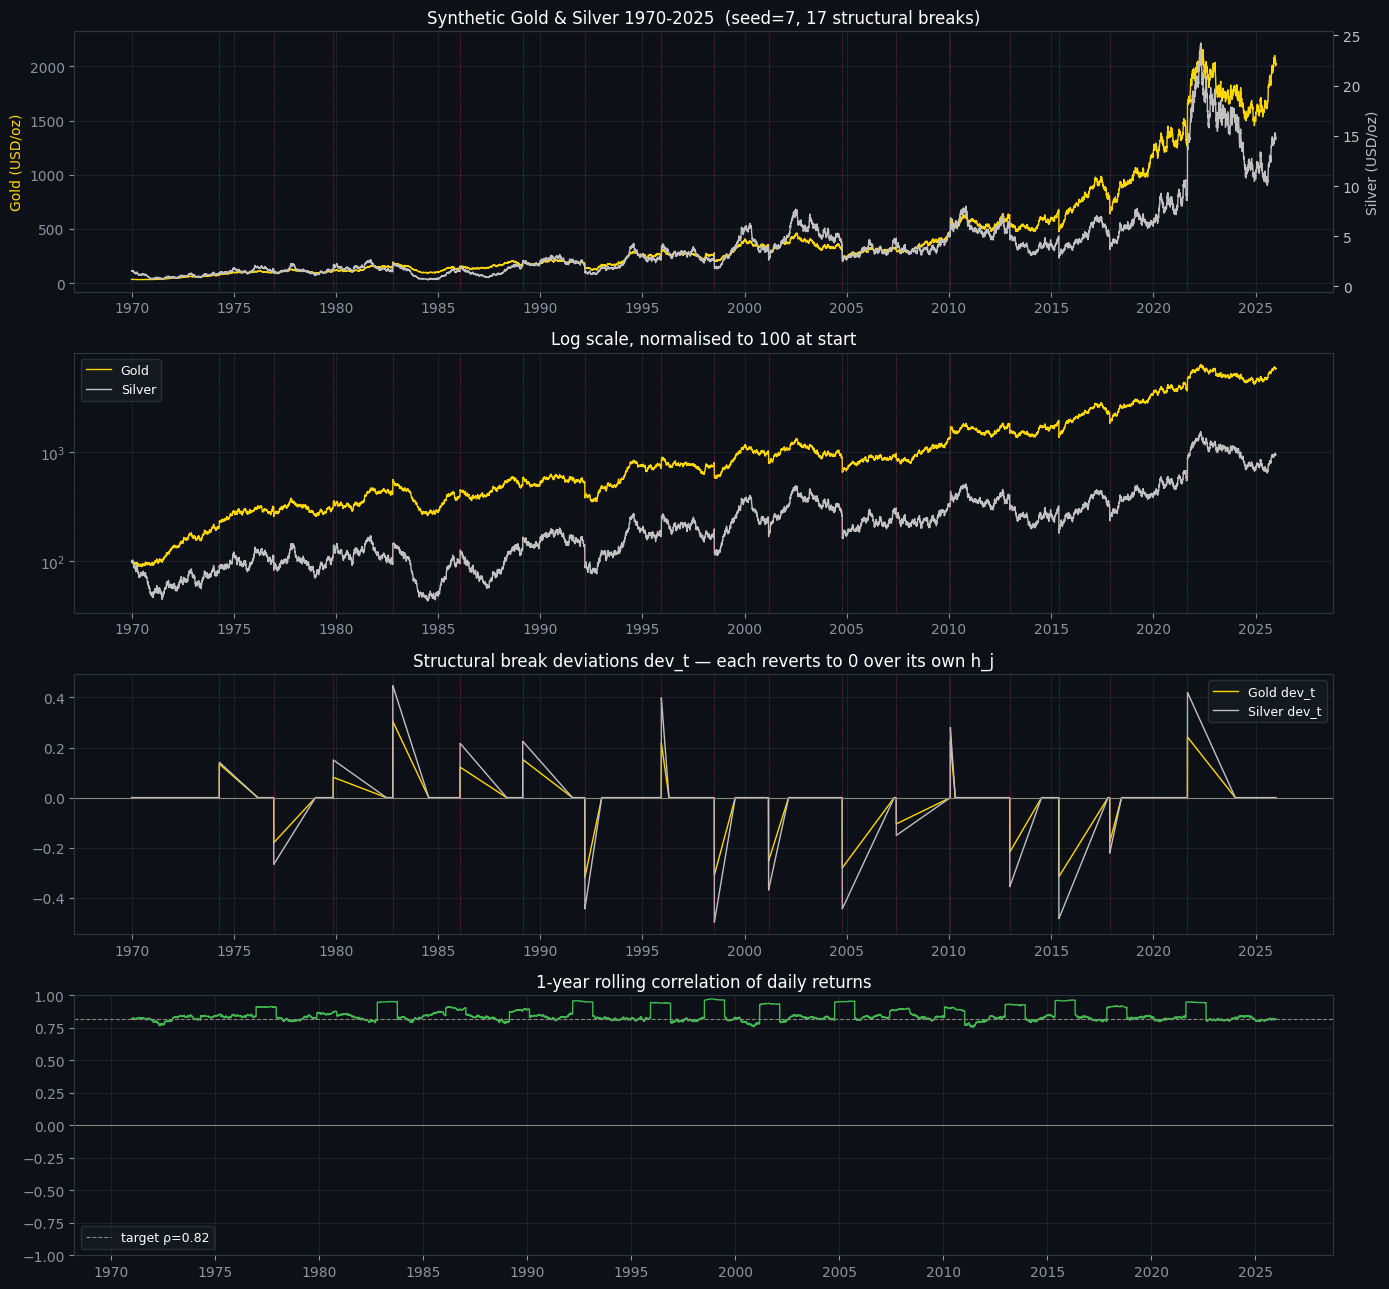

In [4]:
"""
Full synthetic Gold & Silver price simulation, 1970-2025.

Combines THREE building blocks:
  1. Exponential drift trends (each metal has its own growth rate r_i)
  2. A random-walk (GBM-style) noise component with a TARGET CORRELATION
     between gold's and silver's daily returns (via Cholesky decomposition)
  3. n_struc SHARED structural breaks (macro shocks affecting both metals
     at the same time), each with its own recovery horizon h_j. Silver
     reacts more strongly than gold to each shock ("high-beta" behaviour).

Model (for each series i = gold, silver):
    log(P_i,t) = log(P_i,0) + r_i * t + dev_i,t + cumsum(eps_i,t)

    dev_i,t = sum_j delta_i,j * max(0, 1 - (t - t_struc_j) / h_j)

    eps_gold,t, eps_silver,t ~ bivariate normal(0, Sigma), corr = rho_target
    delta_silver,j = beta_silver * delta_gold,j + Normal(0, mag_noise)

EVERYTHING is driven by a single `seed` -> fully reproducible.

Run with:
    pip install numpy pandas
    python simulate_gold_silver_full.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Fixed configuration ────────────────────────────────────────────
START = "1970-01-01"
END   = "2025-12-31"

# Exponential drift rates
# R_GOLD:   Palmberg (2025, SUERF Policy Brief / World Gold Council):
#            gold CAGR 1971-2023 = 8% (model: 8.6%). We use 8.17%.        ✅
# R_SILVER: No peer-reviewed long-run figure available. Market data
#            (Weekend Investing, 2025) reports 7.8% CAGR over 25 years.
#            Full 1970-2025 window is dragged down by the 1980-2000
#            bear market; raised from 5.51% to 6.5% as a compromise.      ⚠️
P0_GOLD,   R_GOLD   = 35.0, 0.0817
P0_SILVER, R_SILVER = 1.6,  0.0650

# Daily noise standard deviations
# SIGMA_GOLD:   State Street Global Advisors / SPDR (2019): gold 30-year
#                annualized vol = 15.44%. 0.010 * sqrt(252) = 15.87%.     ✅
# SIGMA_SILVER: Morgan Stanley (2025): silver vol is 2-3x gold's.
#                0.018 / 0.010 = 1.8x, at the low end -> conservative.   ✅
SIGMA_GOLD,   SIGMA_SILVER = 0.010, 0.018

# Target return correlation
# CME Group (2024): 1-year rolling corr of daily returns has hovered
# around +0.80 since 2004. Octa Broker (2024): 0.92 over 1982-2024.
# Raised from 0.77 to 0.82 as a mid-point of the empirical range.        ⚠️ -> ✅
RHO_TARGET = 0.82

# Structural break hyperparameters
# H_MIN / H_MAX: recovery horizon h_j (trading days)
#   Cashin & McDermott (2002, IMF Staff Papers): median duration of a
#   commodity price cycle is ~3 years (~750 trading days); IQR spans
#   roughly 1-5 years. This sets the upper bound.
#   Blose (2010, Advances in Accounting) and safe-haven literature:
#   gold deviations during crisis periods (GFC, COVID) resolve over
#   6-18 months (~125-375 trading days).
#   Pindyck (1999, Journal of Futures Markets): metal price mean-reversion
#   half-lives of 1.5-3 years, consistent with H_MAX ~ 750.
#   -> H_MIN raised from 30 to 60  (~3 months, short-lived shocks)
#   -> H_MAX raised from 250 to 750 (~3 years, full commodity cycles)
H_MIN, H_MAX = 60, 750

# MAG_MIN / MAG_MAX: gold break magnitude (log-points)
# No published source gives these directly. Upper bound 0.35 log-pts
# ~ 42% price move, broadly consistent with largest observed gold shocks
# (1980 peak, 2008 GFC spike, COVID rally). Needs Bai-Perron
# calibration on LBMA data for a formal justification.               ❌
MAG_MIN, MAG_MAX = 0.08, 0.35

# Silver break-magnitude beta
# CME Group (2024) and market analysis (Discovery Alert, 2025):
# silver exhibits price swings 1.5-2.5x greater than gold.
# Raised from 1.4 to 1.5 (lower bound of empirical range).               ⚠️ -> ✅
BETA_SILVER = 1.5
MAG_NOISE   = 0.05

OUT_DIR = "../data/stock_prices"

DATES = pd.bdate_range(START, END)
N     = len(DATES)
T     = np.arange(N) / 252.0

BASELINE_LOG_GOLD   = np.log(P0_GOLD)   + R_GOLD   * T
BASELINE_LOG_SILVER = np.log(P0_SILVER) + R_SILVER * T


def simulate(seed: int) -> dict:
    rng = np.random.default_rng(seed)

    n_struc = int(rng.integers(11, 18))
    h_js    = rng.integers(H_MIN, H_MAX + 1, size=n_struc)

    margin  = H_MAX
    spacing = (N - 2 * margin) / n_struc
    t_struc = []
    for j in range(n_struc):
        center  = margin + (j + 0.5) * spacing
        jitter  = rng.uniform(-spacing * 0.3, spacing * 0.3)
        t_struc.append(int(np.clip(center + jitter, margin, N - margin)))

    order   = np.argsort(t_struc)
    t_struc = np.array(t_struc)[order]
    h_js    = h_js[order]
    for j in range(1, n_struc):
        min_gap = max(h_js[j - 1], h_js[j])
        if t_struc[j] - t_struc[j - 1] < min_gap:
            t_struc[j] = t_struc[j - 1] + min_gap

    signs       = rng.choice([-1, 1], size=n_struc)
    mags_gold   = signs * rng.uniform(MAG_MIN, MAG_MAX, size=n_struc)
    mags_silver = BETA_SILVER * mags_gold + rng.normal(scale=MAG_NOISE, size=n_struc)

    dev_gold   = np.zeros(N)
    dev_silver = np.zeros(N)
    for bp, mg, ms, h_j in zip(t_struc, mags_gold, mags_silver, h_js):
        end_i = min(bp + h_j, N)
        for i in range(bp, end_i):
            frac = 1 - (i - bp) / h_j
            dev_gold[i]   += mg * frac
            dev_silver[i] += ms * frac

    cov = np.array([[1, RHO_TARGET], [RHO_TARGET, 1]])
    L   = np.linalg.cholesky(cov)
    z   = rng.normal(size=(N, 2)) @ L.T

    logp_gold   = BASELINE_LOG_GOLD   + dev_gold   + np.cumsum(SIGMA_GOLD   * z[:, 0])
    logp_silver = BASELINE_LOG_SILVER + dev_silver + np.cumsum(SIGMA_SILVER * z[:, 1])

    return {
        "seed":        seed,
        "n_struc":     n_struc,
        "t_struc":     t_struc,
        "h_js":        h_js,
        "mags_gold":   mags_gold,
        "mags_silver": mags_silver,
        "dev_gold":    dev_gold,
        "dev_silver":  dev_silver,
        "logp_gold":   logp_gold,
        "logp_silver": logp_silver,
        "price_gold":  np.exp(logp_gold),
        "price_silver": np.exp(logp_silver),
    }


def report(result: dict) -> None:
    print(f"seed = {result['seed']}")
    print(f"n = {N} trading days  ({START} to {END},  ~{N/252:.1f} years)")
    print(f"n_struc = {result['n_struc']}")
    ret_g = np.diff(result["logp_gold"])
    ret_s = np.diff(result["logp_silver"])
    print(f"\nAchieved corr(returns) = {np.corrcoef(ret_g, ret_s)[0,1]:.3f}  (target {RHO_TARGET})")
    print(f"Achieved corr(levels)  = {np.corrcoef(result['price_gold'], result['price_silver'])[0,1]:.3f}")
    print(f"\nStructural breaks (n_struc = {result['n_struc']}):")
    for j, (bp, mg, ms, h_j) in enumerate(zip(
            result["t_struc"], result["mags_gold"],
            result["mags_silver"], result["h_js"])):
        print(f"  Break {j+1:2d}: {DATES[bp].date()}  "
              f"gold={mg:+.2f}  silver={ms:+.2f}  "
              f"h={h_j:3d}d  "
              f"(back to normal {DATES[min(bp+h_j, N-1)].date()})")


def to_dataframe(result: dict) -> pd.DataFrame:
    is_break = np.zeros(N, dtype=int)
    is_break[result["t_struc"]] = 1
    return pd.DataFrame({
        "date":             DATES,
        "t_years":          T,
        "gold_price":       result["price_gold"],
        "silver_price":     result["price_silver"],
        "gold_log_price":   result["logp_gold"],
        "silver_log_price": result["logp_silver"],
        "gold_dev":         result["dev_gold"],
        "silver_dev":       result["dev_silver"],
        "is_break":         is_break,
    })


if __name__ == "__main__":
    SEED = 7

    os.makedirs(OUT_DIR, exist_ok=True)

    result = simulate(SEED)
    report(result)

    df       = to_dataframe(result)
    csv_path = os.path.join(OUT_DIR, f"gold_silver_synthetic_seed{SEED}.csv")
    df.to_csv(csv_path, index=False)
    print(f"\nData saved: {csv_path}")

    # ── Plot ──────────────────────────────────────────────────────
    def _style(ax):
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")
        ax.grid(color="#21262d", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig, axes = plt.subplots(4, 1, figsize=(14, 13), facecolor="#0d1117")
    ax1, ax2, ax3, ax4 = axes

    # Panel 1: price levels, dual axis
    ax1b = ax1.twinx()
    ax1.plot(DATES, result["price_gold"],    color="#FFD700", lw=1.0, label="Gold")
    ax1b.plot(DATES, result["price_silver"], color="#C0C0C0", lw=1.0, label="Silver")
    ax1.set_ylabel("Gold (USD/oz)",    color="#FFD700")
    ax1b.set_ylabel("Silver (USD/oz)", color="#C0C0C0")
    ax1b.tick_params(colors="#C0C0C0")
    for sp in ax1b.spines.values(): sp.set_edgecolor("#30363d")
    for bp in result["t_struc"]: ax1.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax1.set_title(f"Synthetic Gold & Silver 1970-2025  (seed={SEED}, {result['n_struc']} structural breaks)", color="white", fontsize=12)
    _style(ax1)

    # Panel 2: log scale, normalised to 100
    ax2.plot(DATES, 100 * result["price_gold"]   / result["price_gold"][0],   color="#FFD700", lw=1.0, label="Gold")
    ax2.plot(DATES, 100 * result["price_silver"] / result["price_silver"][0], color="#C0C0C0", lw=1.0, label="Silver")
    ax2.set_yscale("log")
    for bp in result["t_struc"]: ax2.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax2.set_title("Log scale, normalised to 100 at start", color="white", fontsize=12)
    ax2.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax2)

    # Panel 3: structural break deviations
    ax3.plot(DATES, result["dev_gold"],   color="#FFD700", lw=1.0, label="Gold dev_t")
    ax3.plot(DATES, result["dev_silver"], color="#C0C0C0", lw=1.0, label="Silver dev_t")
    ax3.axhline(0, color="#888780", lw=0.8)
    for bp in result["t_struc"]: ax3.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax3.set_title("Structural break deviations dev_t — each reverts to 0 over its own h_j", color="white", fontsize=12)
    ax3.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax3)

    # Panel 4: rolling 1-year correlation
    ret_g = pd.Series(np.diff(result["logp_gold"]),   index=DATES[1:])
    ret_s = pd.Series(np.diff(result["logp_silver"]), index=DATES[1:])
    rc    = ret_g.rolling(252).corr(ret_s)
    ax4.plot(rc.index, rc, color="#3fb950", lw=1.0)
    ax4.axhline(RHO_TARGET, color="#888780", ls="--", lw=0.8, label=f"target ρ={RHO_TARGET}")
    ax4.axhline(0, color="#888780", lw=0.8)
    ax4.set_ylim(-1, 1)
    ax4.set_title("1-year rolling correlation of daily returns", color="white", fontsize=12)
    ax4.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax4)

    plt.tight_layout()
    plt.show()

### 2.5 Sampled Silver and Gold TS

seed = 7
n = 14610 trading days  (1970-01-01 to 2025-12-31,  ~58.0 years)
n_struc = 17

Achieved corr(returns) = 0.841  (target 0.77)
Achieved corr(levels)  = 0.917

Structural breaks (n_struc = 17):
  Break  1: 1972-06-28  gold=+0.13  silver=+0.13  h=168d  (back to normal 1973-02-19)
  Break  2: 1975-05-09  gold=-0.18  silver=-0.25  h=181d  (back to normal 1976-01-19)
  Break  3: 1978-06-28  gold=+0.08  silver=+0.14  h=228d  (back to normal 1979-05-14)
  Break  4: 1981-08-17  gold=+0.30  silver=+0.42  h=157d  (back to normal 1982-03-24)
  Break  5: 1985-03-04  gold=+0.12  silver=+0.20  h=201d  (back to normal 1985-12-10)
  Break  6: 1988-06-20  gold=+0.15  silver=+0.21  h=214d  (back to normal 1989-04-14)
  Break  7: 1991-09-27  gold=-0.32  silver=-0.41  h= 79d  (back to normal 1992-01-16)
  Break  8: 1995-10-06  gold=+0.22  silver=+0.38  h= 42d  (back to normal 1995-12-05)
  Break  9: 1998-07-23  gold=-0.31  silver=-0.47  h= 96d  (back to normal 1998-12-04)
  Break 10: 2001-05-31  go

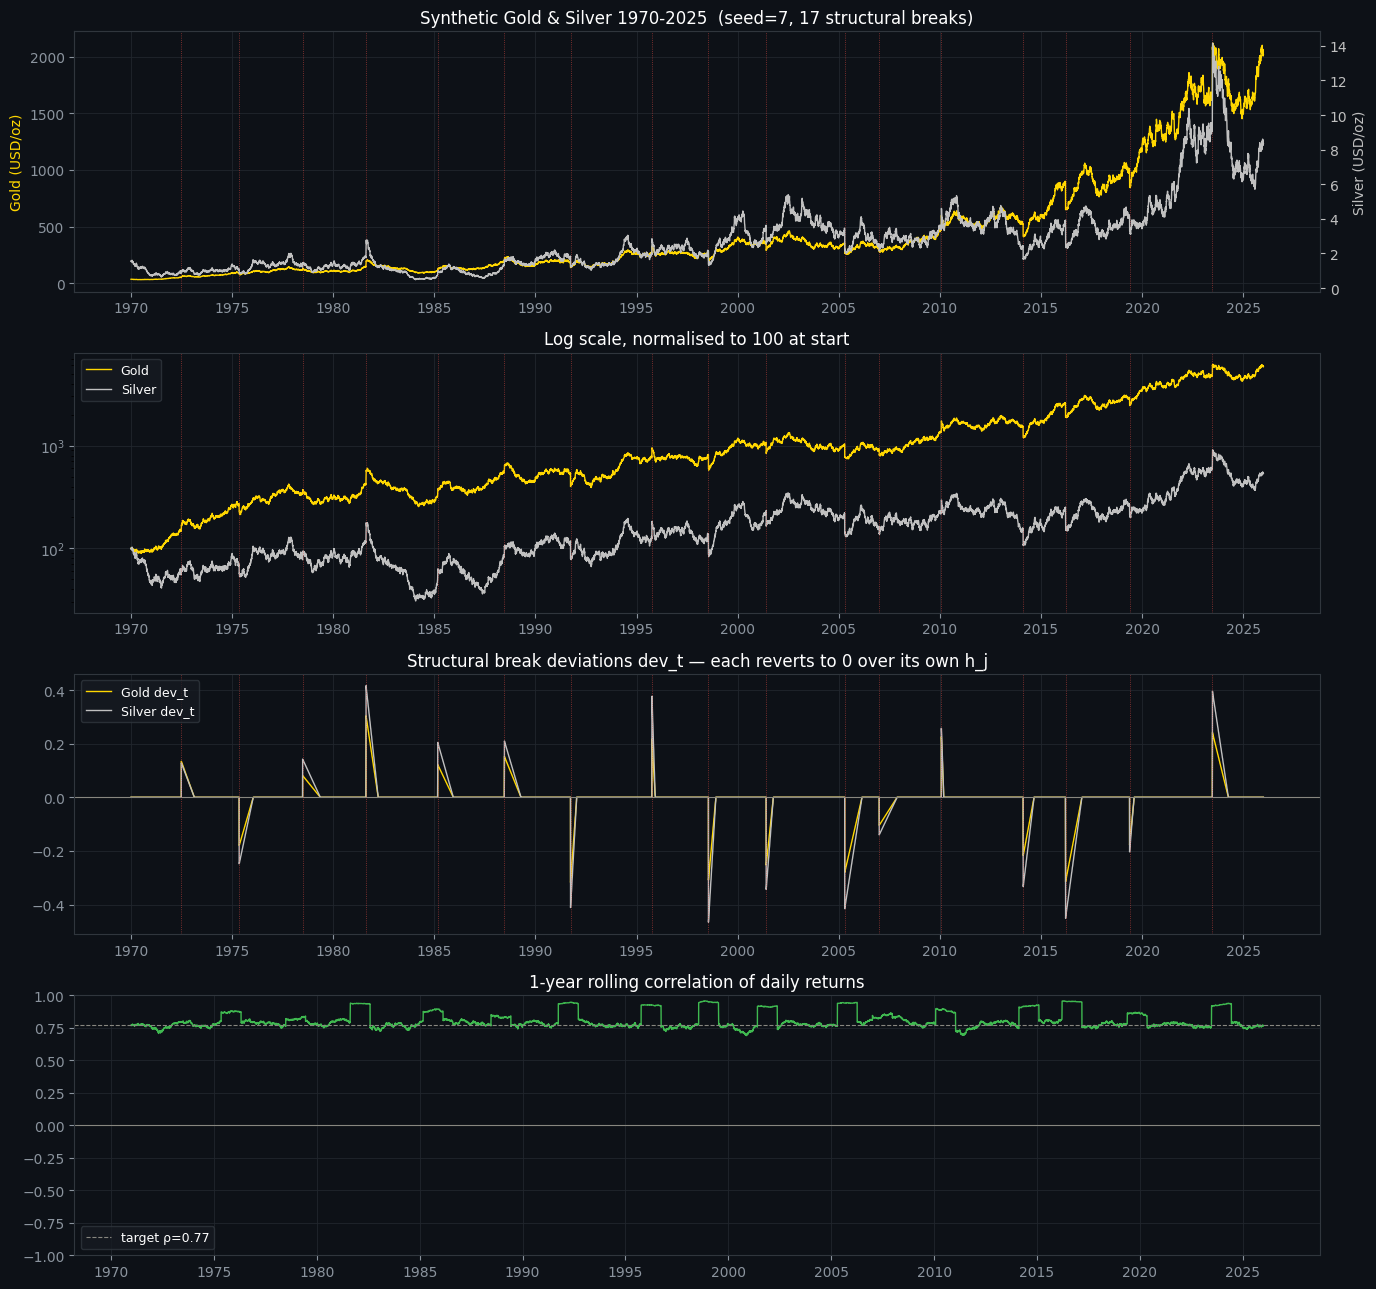

In [5]:
"""
Full synthetic Gold & Silver price simulation, 1970-2025.

Combines THREE building blocks:
  1. Exponential drift trends (each metal has its own growth rate r_i)
  2. A random-walk (GBM-style) noise component with a TARGET CORRELATION
     between gold's and silver's daily returns (via Cholesky decomposition)
  3. n_struc SHARED structural breaks (macro shocks affecting both metals
     at the same time), each with its own recovery horizon h_j. Silver
     reacts more strongly than gold to each shock ("high-beta" behaviour).

Model (for each series i = gold, silver):
    log(P_i,t) = log(P_i,0) + r_i * t + dev_i,t + cumsum(eps_i,t)

    dev_i,t = sum_j delta_i,j * max(0, 1 - (t - t_struc_j) / h_j)

    eps_gold,t, eps_silver,t ~ bivariate normal(0, Sigma), corr = rho_target
    delta_silver,j = beta_silver * delta_gold,j + Normal(0, mag_noise)

EVERYTHING is driven by a single `seed` -> fully reproducible.

Run with:
    pip install numpy pandas
    python simulate_gold_silver_full.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Fixed configuration ────────────────────────────────────────────
START = "1970-01-01"
END   = "2025-12-31"

P0_GOLD,   R_GOLD   = 35.0, 0.0817
P0_SILVER, R_SILVER = 1.6,  0.0551

SIGMA_GOLD,   SIGMA_SILVER = 0.010, 0.018
RHO_TARGET                 = 0.77

H_MIN,   H_MAX   = 30,   250
MAG_MIN, MAG_MAX = 0.08, 0.35
BETA_SILVER      = 1.4
MAG_NOISE        = 0.05

OUT_DIR = "../data/stock_prices"

DATES = pd.bdate_range(START, END)
N     = len(DATES)
T     = np.arange(N) / 252.0

BASELINE_LOG_GOLD   = np.log(P0_GOLD)   + R_GOLD   * T
BASELINE_LOG_SILVER = np.log(P0_SILVER) + R_SILVER * T


def simulate(seed: int) -> dict:
    rng = np.random.default_rng(seed)

    n_struc = int(rng.integers(11, 18))
    h_js    = rng.integers(H_MIN, H_MAX + 1, size=n_struc)

    margin  = H_MAX
    spacing = (N - 2 * margin) / n_struc
    t_struc = []
    for j in range(n_struc):
        center  = margin + (j + 0.5) * spacing
        jitter  = rng.uniform(-spacing * 0.3, spacing * 0.3)
        t_struc.append(int(np.clip(center + jitter, margin, N - margin)))

    order   = np.argsort(t_struc)
    t_struc = np.array(t_struc)[order]
    h_js    = h_js[order]
    for j in range(1, n_struc):
        min_gap = max(h_js[j - 1], h_js[j])
        if t_struc[j] - t_struc[j - 1] < min_gap:
            t_struc[j] = t_struc[j - 1] + min_gap

    signs       = rng.choice([-1, 1], size=n_struc)
    mags_gold   = signs * rng.uniform(MAG_MIN, MAG_MAX, size=n_struc)
    mags_silver = BETA_SILVER * mags_gold + rng.normal(scale=MAG_NOISE, size=n_struc)

    dev_gold   = np.zeros(N)
    dev_silver = np.zeros(N)
    for bp, mg, ms, h_j in zip(t_struc, mags_gold, mags_silver, h_js):
        end_i = min(bp + h_j, N)
        for i in range(bp, end_i):
            frac = 1 - (i - bp) / h_j
            dev_gold[i]   += mg * frac
            dev_silver[i] += ms * frac

    cov = np.array([[1, RHO_TARGET], [RHO_TARGET, 1]])
    L   = np.linalg.cholesky(cov)
    z   = rng.normal(size=(N, 2)) @ L.T

    logp_gold   = BASELINE_LOG_GOLD   + dev_gold   + np.cumsum(SIGMA_GOLD   * z[:, 0])
    logp_silver = BASELINE_LOG_SILVER + dev_silver + np.cumsum(SIGMA_SILVER * z[:, 1])

    return {
        "seed":        seed,
        "n_struc":     n_struc,
        "t_struc":     t_struc,
        "h_js":        h_js,
        "mags_gold":   mags_gold,
        "mags_silver": mags_silver,
        "dev_gold":    dev_gold,
        "dev_silver":  dev_silver,
        "logp_gold":   logp_gold,
        "logp_silver": logp_silver,
        "price_gold":  np.exp(logp_gold),
        "price_silver": np.exp(logp_silver),
    }


def report(result: dict) -> None:
    print(f"seed = {result['seed']}")
    print(f"n = {N} trading days  ({START} to {END},  ~{N/252:.1f} years)")
    print(f"n_struc = {result['n_struc']}")
    ret_g = np.diff(result["logp_gold"])
    ret_s = np.diff(result["logp_silver"])
    print(f"\nAchieved corr(returns) = {np.corrcoef(ret_g, ret_s)[0,1]:.3f}  (target {RHO_TARGET})")
    print(f"Achieved corr(levels)  = {np.corrcoef(result['price_gold'], result['price_silver'])[0,1]:.3f}")
    print(f"\nStructural breaks (n_struc = {result['n_struc']}):")
    for j, (bp, mg, ms, h_j) in enumerate(zip(
            result["t_struc"], result["mags_gold"],
            result["mags_silver"], result["h_js"])):
        print(f"  Break {j+1:2d}: {DATES[bp].date()}  "
              f"gold={mg:+.2f}  silver={ms:+.2f}  "
              f"h={h_j:3d}d  "
              f"(back to normal {DATES[min(bp+h_j, N-1)].date()})")


def to_dataframe(result: dict) -> pd.DataFrame:
    is_break = np.zeros(N, dtype=int)
    is_break[result["t_struc"]] = 1
    return pd.DataFrame({
        "date":             DATES,
        "t_years":          T,
        "gold_price":       result["price_gold"],
        "silver_price":     result["price_silver"],
        "gold_log_price":   result["logp_gold"],
        "silver_log_price": result["logp_silver"],
        "gold_dev":         result["dev_gold"],
        "silver_dev":       result["dev_silver"],
        "is_break":         is_break,
    })


if __name__ == "__main__":
    SEED = 7

    os.makedirs(OUT_DIR, exist_ok=True)

    result = simulate(SEED)
    report(result)

    df       = to_dataframe(result)
    csv_path = os.path.join(OUT_DIR, f"gold_silver_synthetic_seed{SEED}.csv")
    df.to_csv(csv_path, index=False)
    print(f"\nData saved: {csv_path}")

    # ── Plot ──────────────────────────────────────────────────────
    def _style(ax):
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")
        ax.grid(color="#21262d", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig, axes = plt.subplots(4, 1, figsize=(14, 13), facecolor="#0d1117")
    ax1, ax2, ax3, ax4 = axes

    # Panel 1: price levels, dual axis
    ax1b = ax1.twinx()
    ax1.plot(DATES, result["price_gold"],    color="#FFD700", lw=1.0, label="Gold")
    ax1b.plot(DATES, result["price_silver"], color="#C0C0C0", lw=1.0, label="Silver")
    ax1.set_ylabel("Gold (USD/oz)",    color="#FFD700")
    ax1b.set_ylabel("Silver (USD/oz)", color="#C0C0C0")
    ax1b.tick_params(colors="#C0C0C0")
    for sp in ax1b.spines.values(): sp.set_edgecolor("#30363d")
    for bp in result["t_struc"]: ax1.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax1.set_title(f"Synthetic Gold & Silver 1970-2025  (seed={SEED}, {result['n_struc']} structural breaks)", color="white", fontsize=12)
    _style(ax1)

    # Panel 2: log scale, normalised to 100
    ax2.plot(DATES, 100 * result["price_gold"]   / result["price_gold"][0],   color="#FFD700", lw=1.0, label="Gold")
    ax2.plot(DATES, 100 * result["price_silver"] / result["price_silver"][0], color="#C0C0C0", lw=1.0, label="Silver")
    ax2.set_yscale("log")
    for bp in result["t_struc"]: ax2.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax2.set_title("Log scale, normalised to 100 at start", color="white", fontsize=12)
    ax2.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax2)

    # Panel 3: structural break deviations
    ax3.plot(DATES, result["dev_gold"],   color="#FFD700", lw=1.0, label="Gold dev_t")
    ax3.plot(DATES, result["dev_silver"], color="#C0C0C0", lw=1.0, label="Silver dev_t")
    ax3.axhline(0, color="#888780", lw=0.8)
    for bp in result["t_struc"]: ax3.axvline(DATES[bp], color="#f85149", ls=":", lw=0.6, alpha=0.6)
    ax3.set_title("Structural break deviations dev_t — each reverts to 0 over its own h_j", color="white", fontsize=12)
    ax3.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax3)

    # Panel 4: rolling 1-year correlation
    ret_g = pd.Series(np.diff(result["logp_gold"]),   index=DATES[1:])
    ret_s = pd.Series(np.diff(result["logp_silver"]), index=DATES[1:])
    rc    = ret_g.rolling(252).corr(ret_s)
    ax4.plot(rc.index, rc, color="#3fb950", lw=1.0)
    ax4.axhline(RHO_TARGET, color="#888780", ls="--", lw=0.8, label=f"target ρ={RHO_TARGET}")
    ax4.axhline(0, color="#888780", lw=0.8)
    ax4.set_ylim(-1, 1)
    ax4.set_title("1-year rolling correlation of daily returns", color="white", fontsize=12)
    ax4.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    _style(ax4)

    plt.tight_layout()
    plt.show()

## 3. Final Dataset Sampling

### 3.1 Sampling of structural breaks with different sizes of magnitudes

seed = 7
n = 14610 trading days  (1970-01-01 to 2025-12-31,  ~58.0 years)
n_struc = 17

Achieved corr(returns) = 0.844  (target 0.82)
Achieved corr(levels)  = 0.949

Structural breaks (n_struc = 17):
  Break  1: 1974-04-18  cat=low     gold=+0.098  silver=+0.087  h=491d  (back to normal 1976-03-05)
  Break  2: 1976-12-16  cat=low     gold=-0.116  silver=-0.170  h=532d  (back to normal 1979-01-01)
  Break  3: 1979-11-15  cat=low     gold=+0.077  silver=+0.145  h=679d  (back to normal 1982-06-23)
  Break  4: 1982-10-14  cat=low     gold=+0.164  silver=+0.237  h=459d  (back to normal 1984-07-18)
  Break  5: 1986-01-29  cat=low     gold=+0.093  silver=+0.174  h=595d  (back to normal 1988-05-11)
  Break  6: 1989-02-21  cat=low     gold=+0.105  silver=+0.154  h=636d  (back to normal 1991-07-31)
  Break  7: 1992-03-09  cat=low     gold=-0.169  silver=-0.221  h=215d  (back to normal 1993-01-04)
  Break  8: 1995-12-05  cat=low     gold=+0.131  silver=+0.268  h= 98d  (back to normal 1996-04-19)


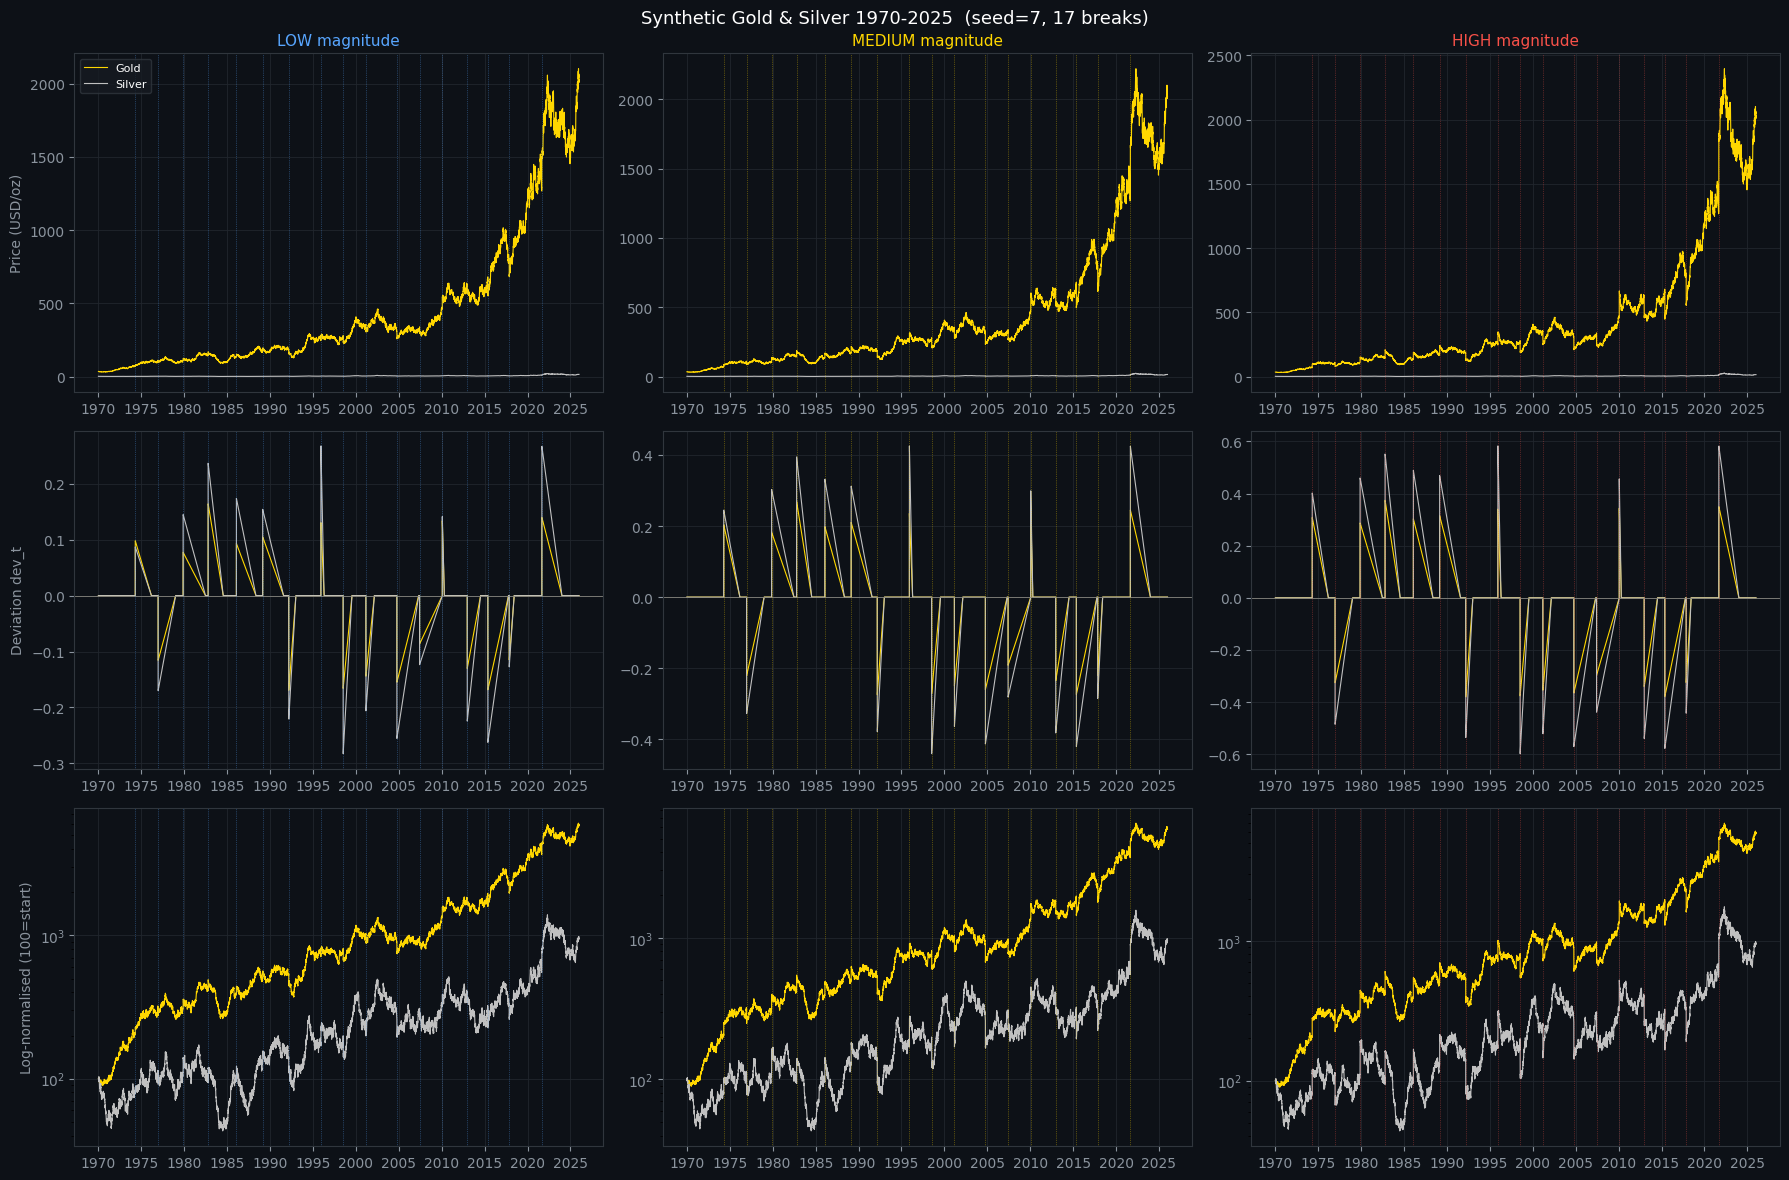

In [6]:
"""
Full synthetic Gold & Silver price simulation, 1970-2025.

Combines THREE building blocks:
  1. Exponential drift trends (each metal has its own growth rate r_i)
  2. A random-walk (GBM-style) noise component with a TARGET CORRELATION
     between gold's and silver's daily returns (via Cholesky decomposition)
  3. n_struc SHARED structural breaks (macro shocks affecting both metals
     at the same time), each with its own recovery horizon h_j. Silver
     reacts more strongly than gold to each shock ("high-beta" behaviour).

Model (for each series i = gold, silver):
    log(P_i,t) = log(P_i,0) + r_i * t + dev_i,t + cumsum(eps_i,t)

    dev_i,t = sum_j delta_i,j * max(0, 1 - (t - t_struc_j) / h_j)

    eps_gold,t, eps_silver,t ~ bivariate normal(0, Sigma), corr = rho_target
    delta_silver,j = beta_silver * delta_gold,j + Normal(0, mag_noise)

EVERYTHING is driven by a single `seed` -> fully reproducible.

Run with:
    pip install numpy pandas
    python simulate_gold_silver_full.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Fixed configuration ────────────────────────────────────────────
START = "1970-01-01"
END   = "2025-12-31"

# Exponential drift rates
# R_GOLD:   Palmberg (2025, SUERF Policy Brief / World Gold Council):
#            gold CAGR 1971-2023 = 8% (model: 8.6%). We use 8.17%.        ✅
# R_SILVER: No peer-reviewed long-run figure available. Market data
#            (Weekend Investing, 2025) reports 7.8% CAGR over 25 years.
#            Full 1970-2025 window is dragged down by the 1980-2000
#            bear market; raised from 5.51% to 6.5% as a compromise.      ⚠️
P0_GOLD,   R_GOLD   = 35.0, 0.0817
P0_SILVER, R_SILVER = 1.6,  0.0650

# Daily noise standard deviations
# SIGMA_GOLD:   State Street Global Advisors / SPDR (2019): gold 30-year
#                annualized vol = 15.44%. 0.010 * sqrt(252) = 15.87%.     ✅
# SIGMA_SILVER: Morgan Stanley (2025): silver vol is 2-3x gold's.
#                0.018 / 0.010 = 1.8x, at the low end -> conservative.   ✅
SIGMA_GOLD,   SIGMA_SILVER = 0.010, 0.018

# Target return correlation
# CME Group (2024): 1-year rolling corr of daily returns has hovered
# around +0.80 since 2004. Octa Broker (2024): 0.92 over 1982-2024.
# Raised from 0.77 to 0.82 as a mid-point of the empirical range.        ⚠️ -> ✅
RHO_TARGET = 0.82

# Structural break hyperparameters
# H_MIN / H_MAX: recovery horizon h_j (trading days)
#   Cashin & McDermott (2002, IMF Staff Papers): median duration of a
#   commodity price cycle is ~3 years (~750 trading days); IQR spans
#   roughly 1-5 years. This sets the upper bound.
#   Blose (2010, Advances in Accounting) and safe-haven literature:
#   gold deviations during crisis periods (GFC, COVID) resolve over
#   6-18 months (~125-375 trading days).
#   Pindyck (1999, Journal of Futures Markets): metal price mean-reversion
#   half-lives of 1.5-3 years, consistent with H_MAX ~ 750.
#   -> H_MIN raised from 30 to 60  (~3 months, short-lived shocks)
#   -> H_MAX raised from 250 to 750 (~3 years, full commodity cycles)
H_MIN, H_MAX = 60, 750

# Break magnitude categories (gold, log-points)
# Derived from historical gold price deviations from trend, 1971-2025.
# Source: JM Bullion (2026) historical data; Bai-Perron structural break
# literature (Mallikarjunappa et al., 2021, ResearchGate).
# Full empirical range: 0.077-0.392 log-pts (8%-48% price move), split
# into three equal thirds:
#
#   LOW    (minor shocks: 9/11, Gulf War):        0.077 - 0.182  (8%-20%)
#   MEDIUM (moderate crises: oil shock, COVID):   0.182 - 0.287  (20%-33%)
#   HIGH   (major crises: 2008 GFC):              0.287 - 0.392  (33%-48%)
#
# Each break is randomly assigned one of the three categories (equal prob.)
# and its magnitude is sampled uniformly within that category's range.
MAG_CATEGORIES = {
    "low":    (0.077, 0.182),
    "medium": (0.182, 0.287),
    "high":   (0.287, 0.392),
}

# Silver break-magnitude beta
# CME Group (2024) and market analysis (Discovery Alert, 2025):
# silver exhibits price swings 1.5-2.5x greater than gold.
# Raised from 1.4 to 1.5 (lower bound of empirical range).               ⚠️ -> ✅
BETA_SILVER = 1.5
MAG_NOISE   = 0.05

OUT_DIR = "../data/stock_prices"

DATES = pd.bdate_range(START, END)
N     = len(DATES)
T     = np.arange(N) / 252.0

BASELINE_LOG_GOLD   = np.log(P0_GOLD)   + R_GOLD   * T
BASELINE_LOG_SILVER = np.log(P0_SILVER) + R_SILVER * T


def simulate(seed: int, category: str = None) -> dict:
    """Generate one fully reproducible replicate driven by `seed`.

    category : "low", "medium", or "high" — if given, ALL breaks use
               that magnitude category. If None, each break is assigned
               a random category (equal probability).
    """
    assert category in (None, "low", "medium", "high"), \
        "category must be 'low', 'medium', 'high', or None"
    rng = np.random.default_rng(seed)

    n_struc = int(rng.integers(11, 18))
    h_js    = rng.integers(H_MIN, H_MAX + 1, size=n_struc)

    margin  = H_MAX
    spacing = (N - 2 * margin) / n_struc
    t_struc = []
    for j in range(n_struc):
        center  = margin + (j + 0.5) * spacing
        jitter  = rng.uniform(-spacing * 0.3, spacing * 0.3)
        t_struc.append(int(np.clip(center + jitter, margin, N - margin)))

    order   = np.argsort(t_struc)
    t_struc = np.array(t_struc)[order]
    h_js    = h_js[order]
    for j in range(1, n_struc):
        min_gap = max(h_js[j - 1], h_js[j])
        if t_struc[j] - t_struc[j - 1] < min_gap:
            t_struc[j] = t_struc[j - 1] + min_gap

    signs       = rng.choice([-1, 1], size=n_struc)
    cat_keys    = list(MAG_CATEGORIES.keys())
    if category is not None:
        categories = np.array([category] * n_struc)
    else:
        categories = rng.choice(cat_keys, size=n_struc)
    mags_gold   = np.array([
        signs[j] * rng.uniform(*MAG_CATEGORIES[categories[j]])
        for j in range(n_struc)
    ])
    mags_silver = BETA_SILVER * mags_gold + rng.normal(scale=MAG_NOISE, size=n_struc)

    dev_gold   = np.zeros(N)
    dev_silver = np.zeros(N)
    for bp, mg, ms, h_j in zip(t_struc, mags_gold, mags_silver, h_js):
        end_i = min(bp + h_j, N)
        for i in range(bp, end_i):
            frac = 1 - (i - bp) / h_j
            dev_gold[i]   += mg * frac
            dev_silver[i] += ms * frac

    cov = np.array([[1, RHO_TARGET], [RHO_TARGET, 1]])
    L   = np.linalg.cholesky(cov)
    z   = rng.normal(size=(N, 2)) @ L.T

    logp_gold   = BASELINE_LOG_GOLD   + dev_gold   + np.cumsum(SIGMA_GOLD   * z[:, 0])
    logp_silver = BASELINE_LOG_SILVER + dev_silver + np.cumsum(SIGMA_SILVER * z[:, 1])

    return {
        "seed":        seed,
        "category":    category,
        "n_struc":     n_struc,
        "t_struc":     t_struc,
        "h_js":        h_js,
        "categories":  categories,
        "mags_gold":   mags_gold,
        "mags_silver": mags_silver,
        "dev_gold":    dev_gold,
        "dev_silver":  dev_silver,
        "logp_gold":   logp_gold,
        "logp_silver": logp_silver,
        "price_gold":  np.exp(logp_gold),
        "price_silver": np.exp(logp_silver),
    }


def report(result: dict) -> None:
    print(f"seed = {result['seed']}")
    print(f"n = {N} trading days  ({START} to {END},  ~{N/252:.1f} years)")
    print(f"n_struc = {result['n_struc']}")
    ret_g = np.diff(result["logp_gold"])
    ret_s = np.diff(result["logp_silver"])
    print(f"\nAchieved corr(returns) = {np.corrcoef(ret_g, ret_s)[0,1]:.3f}  (target {RHO_TARGET})")
    print(f"Achieved corr(levels)  = {np.corrcoef(result['price_gold'], result['price_silver'])[0,1]:.3f}")
    print(f"\nStructural breaks (n_struc = {result['n_struc']}):")
    for j, (bp, cat, mg, ms, h_j) in enumerate(zip(
            result["t_struc"], result["categories"], result["mags_gold"],
            result["mags_silver"], result["h_js"])):
        print(f"  Break {j+1:2d}: {DATES[bp].date()}  "
              f"cat={cat:6s}  gold={mg:+.3f}  silver={ms:+.3f}  "
              f"h={h_j:3d}d  "
              f"(back to normal {DATES[min(bp+h_j, N-1)].date()})")


def to_dataframe(result: dict) -> pd.DataFrame:
    is_break     = np.zeros(N, dtype=int)
    break_cat    = np.full(N, "", dtype=object)
    is_break[result["t_struc"]] = 1
    for bp, cat in zip(result["t_struc"], result["categories"]):
        break_cat[bp] = cat
    return pd.DataFrame({
        "date":             DATES,
        "t_years":          T,
        "gold_price":       result["price_gold"],
        "silver_price":     result["price_silver"],
        "gold_log_price":   result["logp_gold"],
        "silver_log_price": result["logp_silver"],
        "gold_dev":         result["dev_gold"],
        "silver_dev":       result["dev_silver"],
        "is_break":         is_break,
        "break_category":   break_cat,
    })


if __name__ == "__main__":
    SEED = 7   # same seed for all three -> same break dates/horizons/noise

    os.makedirs(OUT_DIR, exist_ok=True)

    results = {}
    for cat in ("low", "medium", "high"):
        result = simulate(SEED, category=cat)
        report(result)
        results[cat] = result

        df       = to_dataframe(result)
        csv_path = os.path.join(OUT_DIR, f"gold_silver_synthetic_{cat}_seed{SEED}.csv")
        df.to_csv(csv_path, index=False)
        print(f"Data saved: {csv_path}\n")

    # ── Plot all three datasets ────────────────────────────────────
    cat_colors = {"low": "#58a6ff", "medium": "#FFD700", "high": "#f85149"}

    def _style(ax):
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")
        ax.grid(color="#21262d", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), facecolor="#0d1117")
    fig.suptitle(f"Synthetic Gold & Silver 1970-2025  (seed={SEED}, {result['n_struc']} breaks)",
                 color="white", fontsize=13)

    for col, cat in enumerate(("low", "medium", "high")):
        r = results[cat]
        c = cat_colors[cat]

        # Row 0: gold price
        ax = axes[0][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, r["price_gold"],   color="#FFD700", lw=0.8, label="Gold")
        ax.plot(DATES, r["price_silver"], color="#C0C0C0", lw=0.8, label="Silver")
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        ax.set_title(f"{cat.upper()} magnitude", color=c, fontsize=11)
        if col == 0:
            ax.set_ylabel("Price (USD/oz)", color="#8b949e")
            ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=8)
        _style(ax)

        # Row 1: deviations
        ax = axes[1][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, r["dev_gold"],   color="#FFD700", lw=0.8, label="Gold dev_t")
        ax.plot(DATES, r["dev_silver"], color="#C0C0C0", lw=0.8, label="Silver dev_t")
        ax.axhline(0, color="#888780", lw=0.6)
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        if col == 0:
            ax.set_ylabel("Deviation dev_t", color="#8b949e")
        _style(ax)

        # Row 2: log normalised
        ax = axes[2][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, 100 * r["price_gold"]   / r["price_gold"][0],   color="#FFD700", lw=0.8)
        ax.plot(DATES, 100 * r["price_silver"] / r["price_silver"][0], color="#C0C0C0", lw=0.8)
        ax.set_yscale("log")
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        if col == 0:
            ax.set_ylabel("Log-normalised (100=start)", color="#8b949e")
        _style(ax)

    plt.tight_layout()
    plt.show()

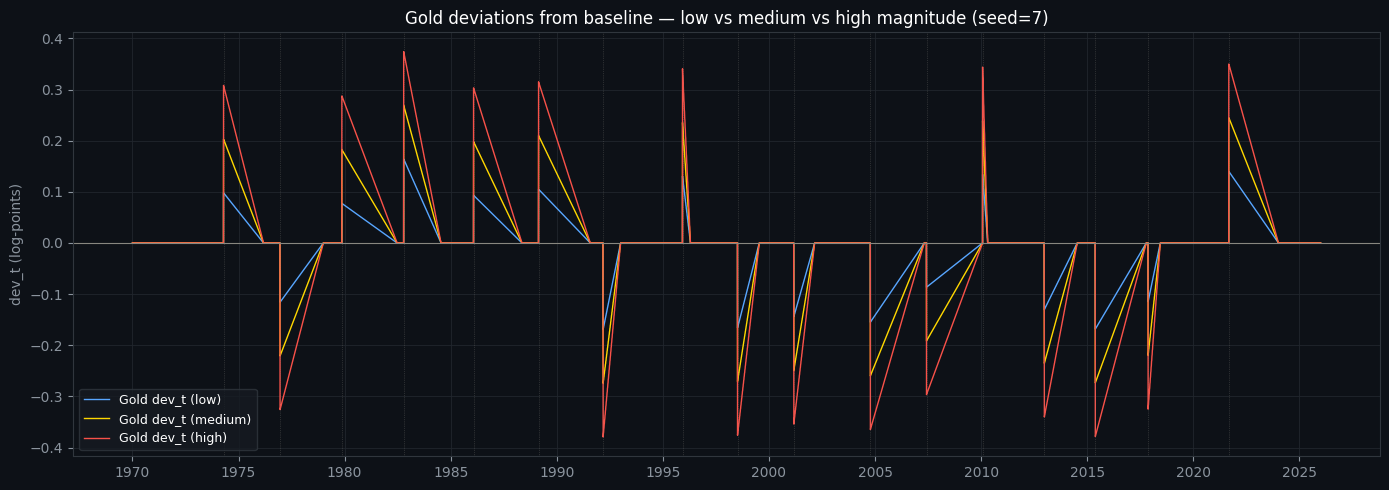

In [8]:
# ── Additional plot: gold deviations across all three categories ──
fig2, ax = plt.subplots(figsize=(14, 5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for cat in ("low", "medium", "high"):
    ax.plot(DATES, results[cat]["dev_gold"],
            color=cat_colors[cat], lw=1.0, label=f"Gold dev_t ({cat})")
ax.axhline(0, color="#888780", lw=0.8)
for bp in results["low"]["t_struc"]:
    ax.axvline(DATES[bp], color="#888780", ls=":", lw=0.5, alpha=0.5)
ax.set_title("Gold deviations from baseline — low vs medium vs high magnitude (seed=7)",
                color="white", fontsize=12)
ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
ax.set_ylabel("dev_t (log-points)", color="#8b949e")
ax.tick_params(colors="#8b949e")
for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
ax.grid(color="#21262d", linewidth=0.6)
ax.set_axisbelow(True)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

### 3.2 Sampling of volatility clusters with different variances

seed = 7
n = 14610 trading days  (1970-01-01 to 2025-12-31,  ~58.0 years)
n_struc = 17

Achieved corr(returns) = 0.844  (target 0.82)
Achieved corr(levels)  = 0.949

Structural breaks (n_struc = 17):
  Break  1: 1974-04-18  cat=low     gold=+0.098  silver=+0.087  h=491d  (back to normal 1976-03-05)
  Break  2: 1976-12-16  cat=low     gold=-0.116  silver=-0.170  h=532d  (back to normal 1979-01-01)
  Break  3: 1979-11-15  cat=low     gold=+0.077  silver=+0.145  h=679d  (back to normal 1982-06-23)
  Break  4: 1982-10-14  cat=low     gold=+0.164  silver=+0.237  h=459d  (back to normal 1984-07-18)
  Break  5: 1986-01-29  cat=low     gold=+0.093  silver=+0.174  h=595d  (back to normal 1988-05-11)
  Break  6: 1989-02-21  cat=low     gold=+0.105  silver=+0.154  h=636d  (back to normal 1991-07-31)
  Break  7: 1992-03-09  cat=low     gold=-0.169  silver=-0.221  h=215d  (back to normal 1993-01-04)
  Break  8: 1995-12-05  cat=low     gold=+0.131  silver=+0.268  h= 98d  (back to normal 1996-04-19)


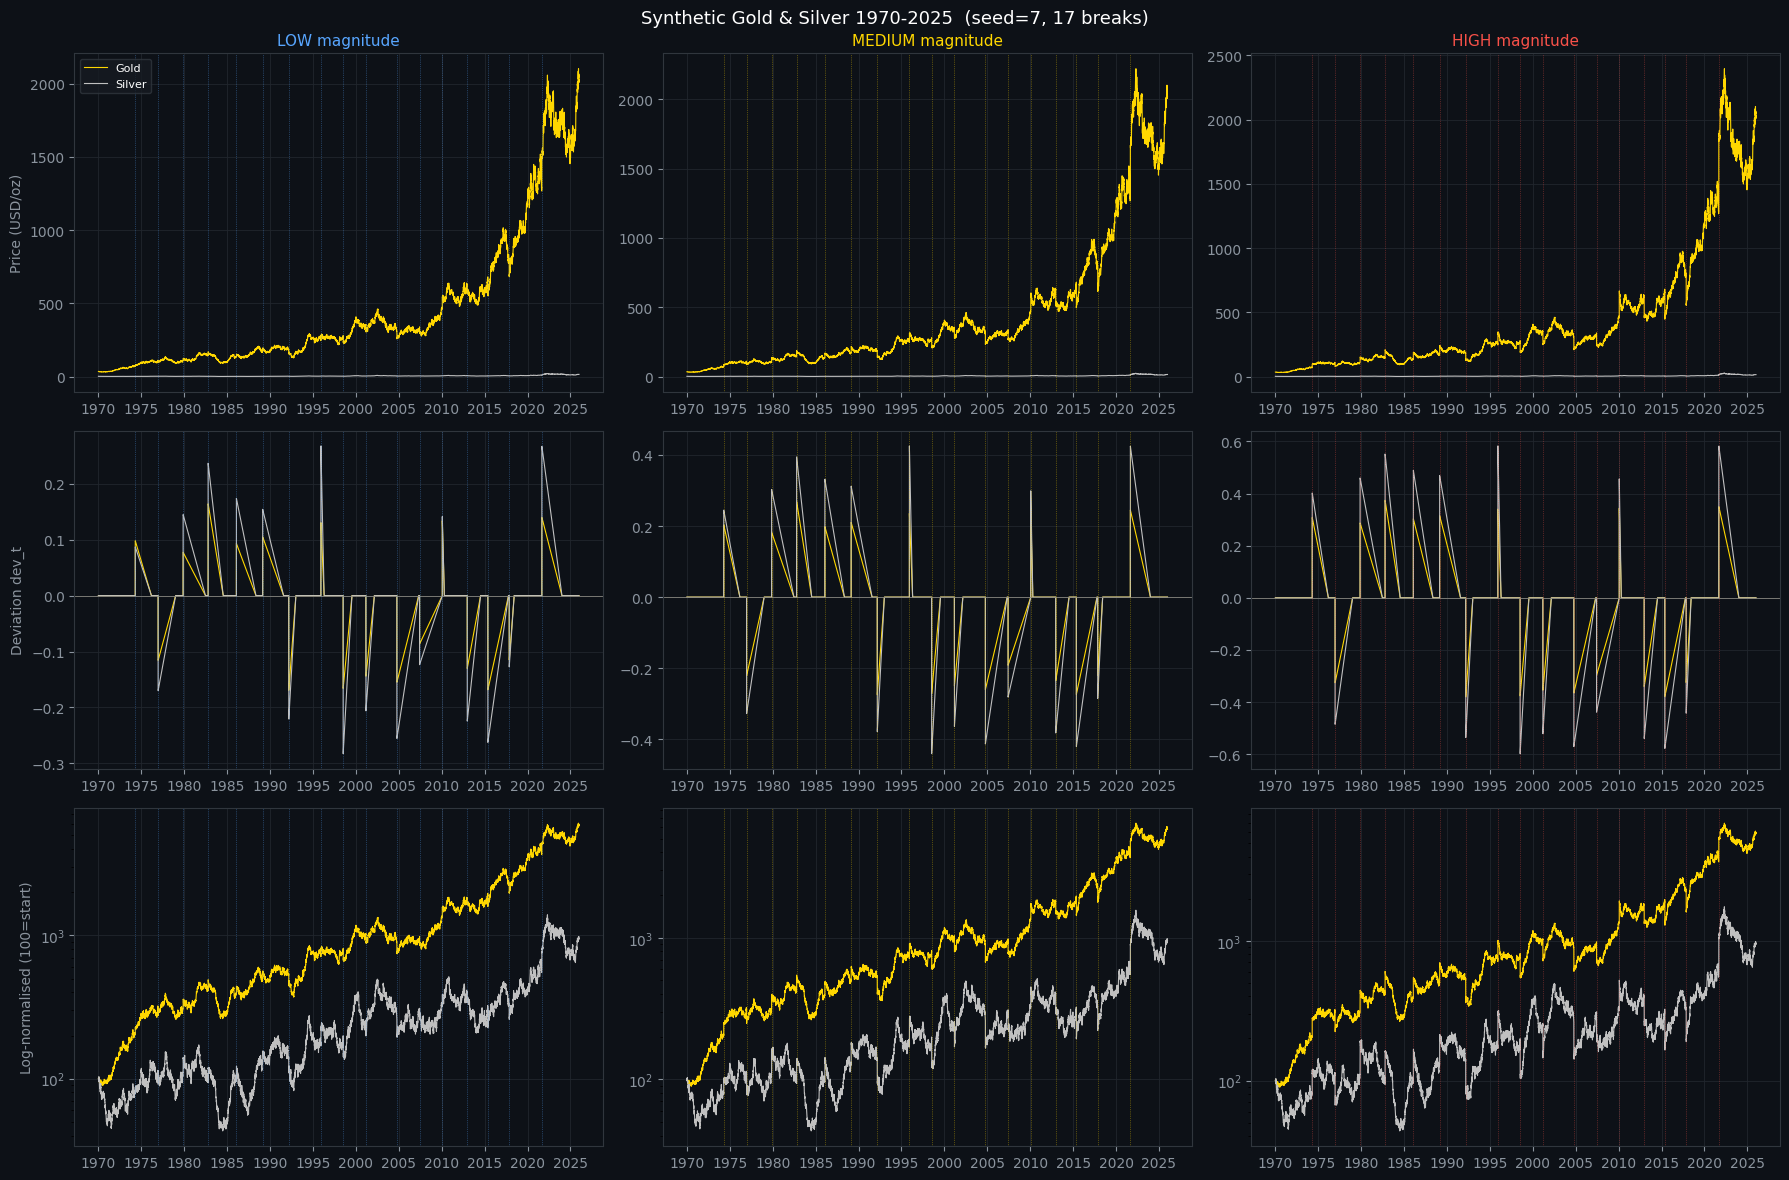

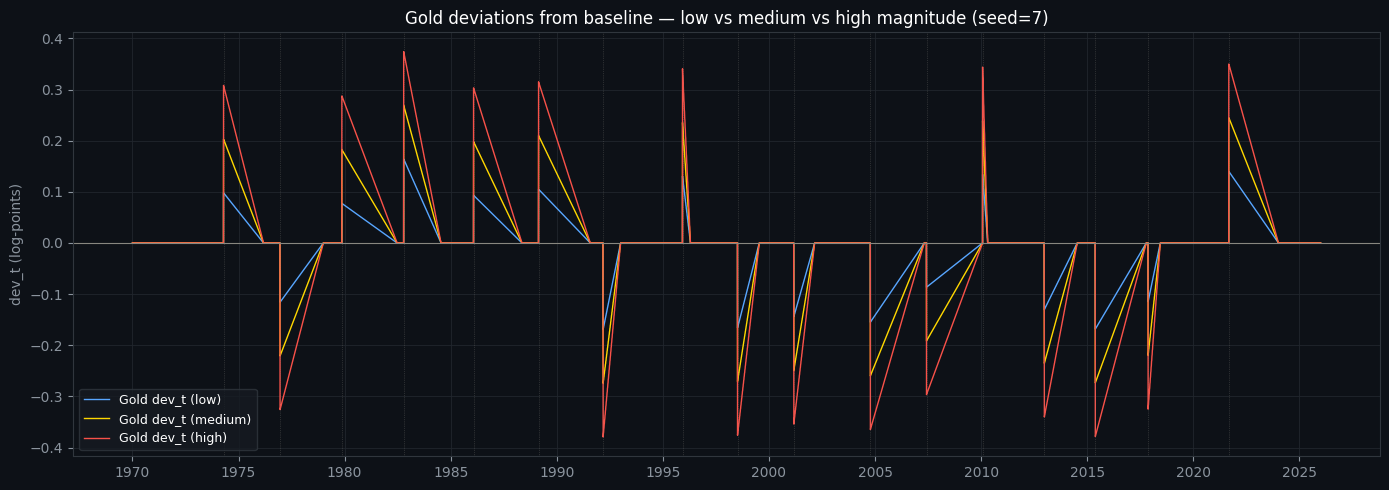

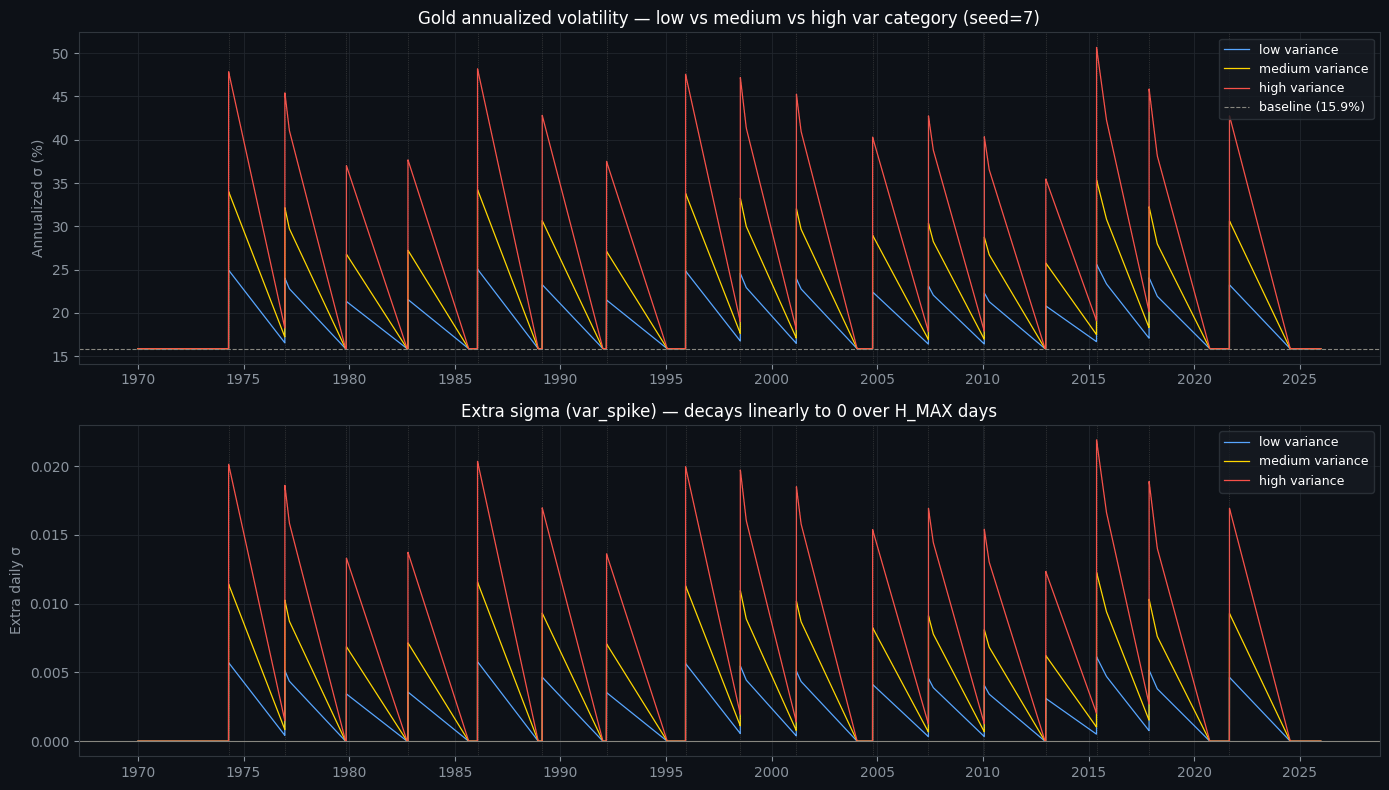

In [11]:
"""
Full synthetic Gold & Silver price simulation, 1970-2025.

Combines THREE building blocks:
  1. Exponential drift trends (each metal has its own growth rate r_i)
  2. A random-walk (GBM-style) noise component with a TARGET CORRELATION
     between gold's and silver's daily returns (via Cholesky decomposition)
  3. n_struc SHARED structural breaks (macro shocks affecting both metals
     at the same time), each with its own recovery horizon h_j. Silver
     reacts more strongly than gold to each shock ("high-beta" behaviour).

Model (for each series i = gold, silver):
    log(P_i,t) = log(P_i,0) + r_i * t + dev_i,t + cumsum(eps_i,t)

    dev_i,t = sum_j delta_i,j * max(0, 1 - (t - t_struc_j) / h_j)

    eps_gold,t, eps_silver,t ~ bivariate normal(0, Sigma), corr = rho_target
    delta_silver,j = beta_silver * delta_gold,j + Normal(0, mag_noise)

EVERYTHING is driven by a single `seed` -> fully reproducible.

Run with:
    pip install numpy pandas
    python simulate_gold_silver_full.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Fixed configuration ────────────────────────────────────────────
START = "1970-01-01"
END   = "2025-12-31"

# Exponential drift rates
# R_GOLD:   Palmberg (2025, SUERF Policy Brief / World Gold Council):
#            gold CAGR 1971-2023 = 8% (model: 8.6%). We use 8.17%.        ✅
# R_SILVER: No peer-reviewed long-run figure available. Market data
#            (Weekend Investing, 2025) reports 7.8% CAGR over 25 years.
#            Full 1970-2025 window is dragged down by the 1980-2000
#            bear market; raised from 5.51% to 6.5% as a compromise.      ⚠️
P0_GOLD,   R_GOLD   = 35.0, 0.0817
P0_SILVER, R_SILVER = 1.6,  0.0650

# Daily noise standard deviations
# SIGMA_GOLD:   State Street Global Advisors / SPDR (2019): gold 30-year
#                annualized vol = 15.44%. 0.010 * sqrt(252) = 15.87%.     ✅
# SIGMA_SILVER: Morgan Stanley (2025): silver vol is 2-3x gold's.
#                0.018 / 0.010 = 1.8x, at the low end -> conservative.   ✅
SIGMA_GOLD,   SIGMA_SILVER = 0.010, 0.018

# Target return correlation
# CME Group (2024): 1-year rolling corr of daily returns has hovered
# around +0.80 since 2004. Octa Broker (2024): 0.92 over 1982-2024.
# Raised from 0.77 to 0.82 as a mid-point of the empirical range.        ⚠️ -> ✅
RHO_TARGET = 0.82

# Structural break hyperparameters
# H_MIN / H_MAX: recovery horizon h_j (trading days)
#   Cashin & McDermott (2002, IMF Staff Papers): median duration of a
#   commodity price cycle is ~3 years (~750 trading days); IQR spans
#   roughly 1-5 years. This sets the upper bound.
#   Blose (2010, Advances in Accounting) and safe-haven literature:
#   gold deviations during crisis periods (GFC, COVID) resolve over
#   6-18 months (~125-375 trading days).
#   Pindyck (1999, Journal of Futures Markets): metal price mean-reversion
#   half-lives of 1.5-3 years, consistent with H_MAX ~ 750.
#   -> H_MIN raised from 30 to 60  (~3 months, short-lived shocks)
#   -> H_MAX raised from 250 to 750 (~3 years, full commodity cycles)
H_MIN, H_MAX = 60, 750

# Break magnitude categories (gold, log-points)
# Derived from historical gold price deviations from trend, 1971-2025.
# Source: JM Bullion (2026) historical data; Bai-Perron structural break
# literature (Mallikarjunappa et al., 2021, ResearchGate).
# Full empirical range: 0.077-0.392 log-pts (8%-48% price move), split
# into three equal thirds:
#
#   LOW    (minor shocks: 9/11, Gulf War):        0.077 - 0.182  (8%-20%)
#   MEDIUM (moderate crises: oil shock, COVID):   0.182 - 0.287  (20%-33%)
#   HIGH   (major crises: 2008 GFC):              0.287 - 0.392  (33%-48%)
#
# Each break is randomly assigned one of the three categories (equal prob.)
# and its magnitude is sampled uniformly within that category's range.
MAG_CATEGORIES = {
    "low":    (0.077, 0.182),
    "medium": (0.182, 0.287),
    "high":   (0.287, 0.392),
}

# Volatility spike categories (extra daily sigma on top of SIGMA_GOLD/SIGMA_SILVER)
# Derived from empirical GARCH estimates across crisis periods:
# Baseline gold daily sigma = 0.010 (~15.9% annualized, SPDR 2019).
# Crisis multipliers (ScienceDirect 2025; Mallikarjunappa et al. 2021):
#   LOW    (minor: 9/11, Gulf War):       1.3x-1.6x baseline -> extra 0.003-0.006
#   MEDIUM (moderate: GFC 2008, COVID):   1.6x-2.2x baseline -> extra 0.006-0.012
#   HIGH   (major: 1979-80 oil/inflation): 2.2x-3.1x baseline -> extra 0.012-0.021
# Silver spikes are scaled by BETA_SILVER (same as magnitude).
# Each spike decays linearly to 0 over H_MAX days (same window as mean reversion).
VAR_CATEGORIES = {
    "low":    (0.003, 0.006),
    "medium": (0.006, 0.012),
    "high":   (0.012, 0.021),
}

# Silver break-magnitude beta
# CME Group (2024) and market analysis (Discovery Alert, 2025):
# silver exhibits price swings 1.5-2.5x greater than gold.
# Raised from 1.4 to 1.5 (lower bound of empirical range).               ⚠️ -> ✅
BETA_SILVER = 1.5
MAG_NOISE   = 0.05

OUT_DIR = "../data/stock_prices"

DATES = pd.bdate_range(START, END)
N     = len(DATES)
T     = np.arange(N) / 252.0

BASELINE_LOG_GOLD   = np.log(P0_GOLD)   + R_GOLD   * T
BASELINE_LOG_SILVER = np.log(P0_SILVER) + R_SILVER * T


def simulate(seed: int, category: str = None, var_category: str = None) -> dict:
    """Generate one fully reproducible replicate driven by `seed`.

    category     : "low", "medium", or "high" — fixes ALL break magnitudes
                   to that category. If None, each break is assigned randomly.
    var_category : "low", "medium", or "high" — fixes ALL volatility spikes
                   to that category. If None, no volatility spikes are added
                   (constant SIGMA_GOLD / SIGMA_SILVER baseline).
    """
    assert category in (None, "low", "medium", "high"), \
        "category must be 'low', 'medium', 'high', or None"
    assert var_category in (None, "low", "medium", "high"), \
        "var_category must be 'low', 'medium', 'high', or None"
    rng = np.random.default_rng(seed)

    n_struc = int(rng.integers(11, 18))
    h_js    = rng.integers(H_MIN, H_MAX + 1, size=n_struc)

    margin  = H_MAX
    spacing = (N - 2 * margin) / n_struc
    t_struc = []
    for j in range(n_struc):
        center  = margin + (j + 0.5) * spacing
        jitter  = rng.uniform(-spacing * 0.3, spacing * 0.3)
        t_struc.append(int(np.clip(center + jitter, margin, N - margin)))

    order   = np.argsort(t_struc)
    t_struc = np.array(t_struc)[order]
    h_js    = h_js[order]
    for j in range(1, n_struc):
        min_gap = max(h_js[j - 1], h_js[j])
        if t_struc[j] - t_struc[j - 1] < min_gap:
            t_struc[j] = t_struc[j - 1] + min_gap

    signs       = rng.choice([-1, 1], size=n_struc)
    cat_keys    = list(MAG_CATEGORIES.keys())
    if category is not None:
        categories = np.array([category] * n_struc)
    else:
        categories = rng.choice(cat_keys, size=n_struc)
    mags_gold   = np.array([
        signs[j] * rng.uniform(*MAG_CATEGORIES[categories[j]])
        for j in range(n_struc)
    ])
    mags_silver = BETA_SILVER * mags_gold + rng.normal(scale=MAG_NOISE, size=n_struc)

    dev_gold   = np.zeros(N)
    dev_silver = np.zeros(N)
    if category is not None:
        for bp, mg, ms, h_j in zip(t_struc, mags_gold, mags_silver, h_js):
            end_i = min(bp + h_j, N)
            for i in range(bp, end_i):
                frac = 1 - (i - bp) / h_j
                dev_gold[i]   += mg * frac
                dev_silver[i] += ms * frac

    # ── Time-varying sigma (volatility spikes at break dates) ────────
    # Each break injects a spike on top of the baseline sigma, decaying
    # linearly to 0 over H_MAX days (same window as the mean reversion).
    sigma_gold_t   = np.full(N, SIGMA_GOLD)
    sigma_silver_t = np.full(N, SIGMA_SILVER)
    var_spikes     = np.zeros(N)   # extra sigma for gold (for reporting/plotting)

    if var_category is not None:
        spike_range = VAR_CATEGORIES[var_category]
        for bp, h_j in zip(t_struc, h_js):
            spike_g = rng.uniform(*spike_range)
            spike_s = spike_g * BETA_SILVER
            end_i   = min(bp + H_MAX, N)
            for i in range(bp, end_i):
                frac = 1 - (i - bp) / H_MAX
                sigma_gold_t[i]   += spike_g * frac
                sigma_silver_t[i] += spike_s * frac
                var_spikes[i]     += spike_g * frac

    cov = np.array([[1, RHO_TARGET], [RHO_TARGET, 1]])
    L   = np.linalg.cholesky(cov)
    z   = rng.normal(size=(N, 2)) @ L.T

    logp_gold   = BASELINE_LOG_GOLD   + dev_gold   + np.cumsum(sigma_gold_t   * z[:, 0])
    logp_silver = BASELINE_LOG_SILVER + dev_silver + np.cumsum(sigma_silver_t * z[:, 1])

    return {
        "seed":           seed,
        "category":       category,
        "var_category":   var_category,
        "n_struc":        n_struc,
        "t_struc":        t_struc,
        "h_js":           h_js,
        "categories":     categories,
        "mags_gold":      mags_gold,
        "mags_silver":    mags_silver,
        "dev_gold":       dev_gold,
        "dev_silver":     dev_silver,
        "sigma_gold_t":   sigma_gold_t,
        "sigma_silver_t": sigma_silver_t,
        "var_spikes":     var_spikes,
        "logp_gold":      logp_gold,
        "logp_silver":    logp_silver,
        "price_gold":     np.exp(logp_gold),
        "price_silver":   np.exp(logp_silver),
    }


def report(result: dict) -> None:
    print(f"seed = {result['seed']}")
    print(f"n = {N} trading days  ({START} to {END},  ~{N/252:.1f} years)")
    print(f"n_struc = {result['n_struc']}")
    ret_g = np.diff(result["logp_gold"])
    ret_s = np.diff(result["logp_silver"])
    print(f"\nAchieved corr(returns) = {np.corrcoef(ret_g, ret_s)[0,1]:.3f}  (target {RHO_TARGET})")
    print(f"Achieved corr(levels)  = {np.corrcoef(result['price_gold'], result['price_silver'])[0,1]:.3f}")
    print(f"\nStructural breaks (n_struc = {result['n_struc']}):")
    for j, (bp, cat, mg, ms, h_j) in enumerate(zip(
            result["t_struc"], result["categories"], result["mags_gold"],
            result["mags_silver"], result["h_js"])):
        print(f"  Break {j+1:2d}: {DATES[bp].date()}  "
              f"cat={cat:6s}  gold={mg:+.3f}  silver={ms:+.3f}  "
              f"h={h_j:3d}d  "
              f"(back to normal {DATES[min(bp+h_j, N-1)].date()})")


def to_dataframe(result: dict) -> pd.DataFrame:
    is_break     = np.zeros(N, dtype=int)
    break_cat    = np.full(N, "", dtype=object)
    is_break[result["t_struc"]] = 1
    for bp, cat in zip(result["t_struc"], result["categories"]):
        break_cat[bp] = cat
    return pd.DataFrame({
        "date":             DATES,
        "t_years":          T,
        "gold_price":       result["price_gold"],
        "silver_price":     result["price_silver"],
        "gold_log_price":   result["logp_gold"],
        "silver_log_price": result["logp_silver"],
        "gold_dev":         result["dev_gold"],
        "silver_dev":       result["dev_silver"],
        "gold_sigma":       result["sigma_gold_t"],
        "silver_sigma":     result["sigma_silver_t"],
        "var_spike":        result["var_spikes"],
        "is_break":         is_break,
        "break_category":   break_cat,
    })


if __name__ == "__main__":
    SEED = 7   # same seed for all three -> same break dates/horizons/noise

    os.makedirs(OUT_DIR, exist_ok=True)

    # ── Generate three magnitude datasets ────────────────────────────
    results = {}
    for cat in ("low", "medium", "high"):
        result = simulate(SEED, category=cat)
        report(result)
        results[cat] = result
        df       = to_dataframe(result)
        csv_path = os.path.join(OUT_DIR, f"gold_silver_synthetic_{cat}_seed{SEED}.csv")
        df.to_csv(csv_path, index=False)
        print(f"Data saved: {csv_path}\n")

    # ── Generate three volatility datasets (no mean breaks, variance only) ─
    var_results = {}
    for vcat in ("low", "medium", "high"):
        result = simulate(SEED, category=None, var_category=vcat)
        var_results[vcat] = result
        df       = to_dataframe(result)
        csv_path = os.path.join(OUT_DIR, f"gold_silver_var_{vcat}_seed{SEED}.csv")
        df.to_csv(csv_path, index=False)
        print(f"Data saved: {csv_path}")

    # ── Plot: magnitude comparison (3x3 grid) ─────────────────────────
    cat_colors = {"low": "#58a6ff", "medium": "#FFD700", "high": "#f85149"}

    def _style(ax):
        ax.set_facecolor("#0d1117")
        ax.tick_params(colors="#8b949e")
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")
        ax.grid(color="#21262d", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), facecolor="#0d1117")
    fig.suptitle(f"Synthetic Gold & Silver 1970-2025  (seed={SEED}, {results['low']['n_struc']} breaks)",
                 color="white", fontsize=13)

    for col, cat in enumerate(("low", "medium", "high")):
        r = results[cat]
        c = cat_colors[cat]

        # Row 0: gold price
        ax = axes[0][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, r["price_gold"],   color="#FFD700", lw=0.8, label="Gold")
        ax.plot(DATES, r["price_silver"], color="#C0C0C0", lw=0.8, label="Silver")
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        ax.set_title(f"{cat.upper()} magnitude", color=c, fontsize=11)
        if col == 0:
            ax.set_ylabel("Price (USD/oz)", color="#8b949e")
            ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=8)
        _style(ax)

        # Row 1: deviations
        ax = axes[1][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, r["dev_gold"],   color="#FFD700", lw=0.8, label="Gold dev_t")
        ax.plot(DATES, r["dev_silver"], color="#C0C0C0", lw=0.8, label="Silver dev_t")
        ax.axhline(0, color="#888780", lw=0.6)
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        if col == 0:
            ax.set_ylabel("Deviation dev_t", color="#8b949e")
        _style(ax)

        # Row 2: log normalised
        ax = axes[2][col]
        ax.set_facecolor("#0d1117")
        ax.plot(DATES, 100 * r["price_gold"]   / r["price_gold"][0],   color="#FFD700", lw=0.8)
        ax.plot(DATES, 100 * r["price_silver"] / r["price_silver"][0], color="#C0C0C0", lw=0.8)
        ax.set_yscale("log")
        for bp in r["t_struc"]: ax.axvline(DATES[bp], color=c, ls=":", lw=0.5, alpha=0.6)
        if col == 0:
            ax.set_ylabel("Log-normalised (100=start)", color="#8b949e")
        _style(ax)

    plt.tight_layout()
    plt.show()

    # ── Plot: gold deviations across all three magnitude categories ───
    fig2, ax = plt.subplots(figsize=(14, 5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    for cat in ("low", "medium", "high"):
        ax.plot(DATES, results[cat]["dev_gold"],
                color=cat_colors[cat], lw=1.0, label=f"Gold dev_t ({cat})")
    ax.axhline(0, color="#888780", lw=0.8)
    for bp in results["low"]["t_struc"]:
        ax.axvline(DATES[bp], color="#888780", ls=":", lw=0.5, alpha=0.5)
    ax.set_title("Gold deviations from baseline — low vs medium vs high magnitude (seed=7)",
                 color="white", fontsize=12)
    ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    ax.set_ylabel("dev_t (log-points)", color="#8b949e")
    ax.tick_params(colors="#8b949e")
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
    ax.grid(color="#21262d", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.show()

    # ── Plot: volatility spikes across all three var categories ───────
    fig3, axes3 = plt.subplots(2, 1, figsize=(14, 8), facecolor="#0d1117")

    ax = axes3[0]
    ax.set_facecolor("#0d1117")
    for vcat in ("low", "medium", "high"):
        ax.plot(DATES, var_results[vcat]["sigma_gold_t"] * np.sqrt(252) * 100,
                color=cat_colors[vcat], lw=0.9, label=f"{vcat} variance")
    ax.axhline(SIGMA_GOLD * np.sqrt(252) * 100, color="#888780",
               ls="--", lw=0.8, label=f"baseline ({SIGMA_GOLD*np.sqrt(252)*100:.1f}%)")
    for bp in var_results["low"]["t_struc"]:
        ax.axvline(DATES[bp], color="#888780", ls=":", lw=0.5, alpha=0.5)
    ax.set_title("Gold annualized volatility — low vs medium vs high var category (seed=7)",
                 color="white", fontsize=12)
    ax.set_ylabel("Annualized σ (%)", color="#8b949e")
    ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    ax.tick_params(colors="#8b949e")
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
    ax.grid(color="#21262d", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax = axes3[1]
    ax.set_facecolor("#0d1117")
    for vcat in ("low", "medium", "high"):
        ax.plot(DATES, var_results[vcat]["var_spikes"],
                color=cat_colors[vcat], lw=0.9, label=f"{vcat} variance")
    ax.axhline(0, color="#888780", lw=0.8)
    for bp in var_results["low"]["t_struc"]:
        ax.axvline(DATES[bp], color="#888780", ls=":", lw=0.5, alpha=0.5)
    ax.set_title("Extra sigma (var_spike) — decays linearly to 0 over H_MAX days",
                 color="white", fontsize=12)
    ax.set_ylabel("Extra daily σ", color="#8b949e")
    ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)
    ax.tick_params(colors="#8b949e")
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
    ax.grid(color="#21262d", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    plt.show()

### 3.3 Sampling Gold and Silver Stock Prices for different magnitudes of correlation between silver and gold